# PS1 - Financial Econometrics
### Identifying Stationarity, Log transformations, and differencing.
Group members: Micha Balsiger,  Carlos Rubiano, Juan Pablo Duque"
due date: 2026-01-23



# GDPUSA

The data is available on the official website http://www.bea.gov/national/index.htm
and corresponds to the Gross Domestic Product (GDP) of the United States. These are
quarterly data representing the chained volume in billions of dollars (2009), seasonally adjusted,
from Q1/1947 until Q4/2019

In [ ]:
# 1) Load the data file (adjust the filename if needed

gdp_raw <- scan("/content/sample_data/GDPUSA.dat")     # works if the .dat is a single numeric column

# 2) Convert to a quarterly time series: from 1947 Q1, frequency = 4
GDPUSA <- ts(gdp_raw, start = c(1947, 1), frequency = 4)
gdp_raw <- read.table("/content/sample_data/GDPUSA.dat", header = FALSE)
GDPUSA  <- ts(gdp_raw[,1], start = c(1947, 1), frequency = 4)

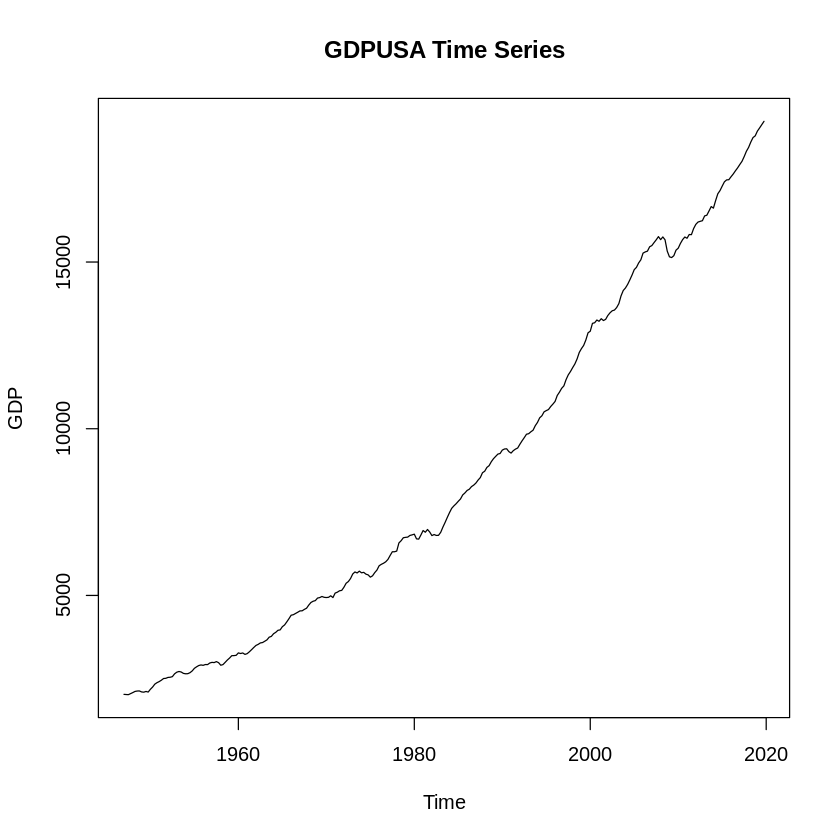

In [ ]:
# Plot the GDPUSA time series
plot(GDPUSA,
     main = "GDPUSA Time Series",
     ylab = "GDP",
     xlab = "Time")

**Visual Characteristics:**


*   Strong upward trend with a change in slope (non-linear trend, even an exponential trend is plausible). This clear trend implies a non-constant mean in levels.
*   No obvious seasonality
*   Business cycle type of fluctuations with short-run expansions and contractions.
* Fluctuations around the trend become larger as the level of GDP increases, suggesting that the variance is not constant and may scale with the size of the economy. Periods of economic contraction are visible as temporary slowdowns or declines relative to the trend, notably during major recessions, but no regular seasonal pattern is apparent, consistent with the series being seasonally adjusted.




**Is Variance Constant? (USAGDP)**

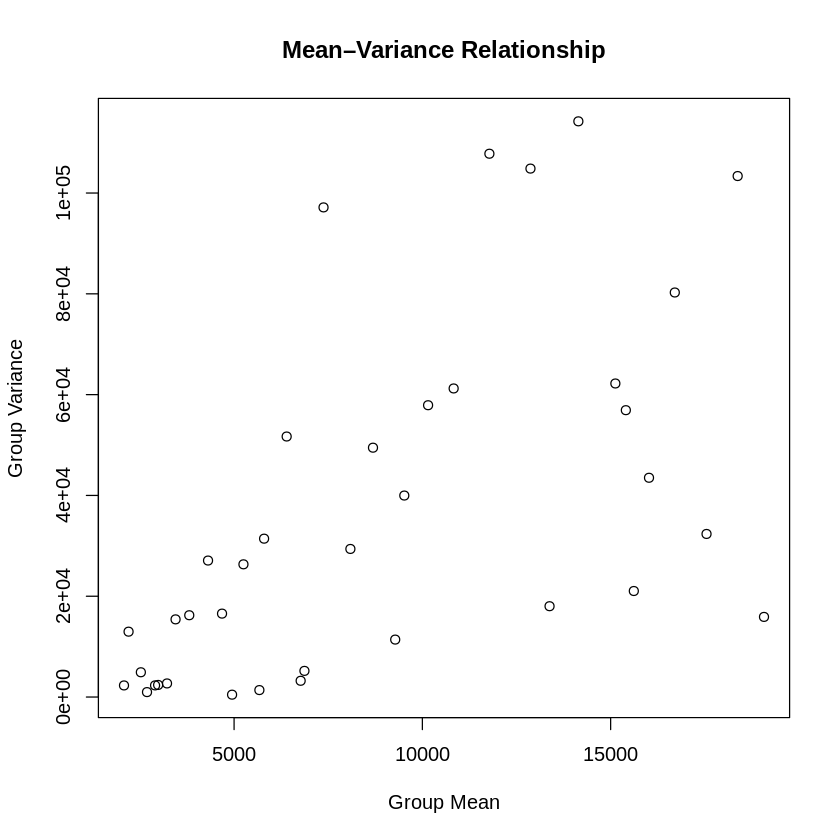

In [ ]:
# Convert series to numeric
y <- as.numeric(GDPUSA)

# Create grouping index: every 8 observations (2 years)
group <- rep(1:ceiling(length(y)/8), each = 8)[1:length(y)]

# Compute mean and variance by group
group_mean <- tapply(y, group, mean)
group_var  <- tapply(y, group, var)

# Plot mean–variance relationship
plot(group_mean, group_var,
     xlab = "Group Mean",
     ylab = "Group Variance",
     main = "Mean–Variance Relationship")




Mean-Variance Plot: There is a clear positive relationship between the group mean and group variance. As the average GDP level increases across 2-year periods, the variance also increases. This indicates that the variance of the series is not constant and grows with the level of the series.


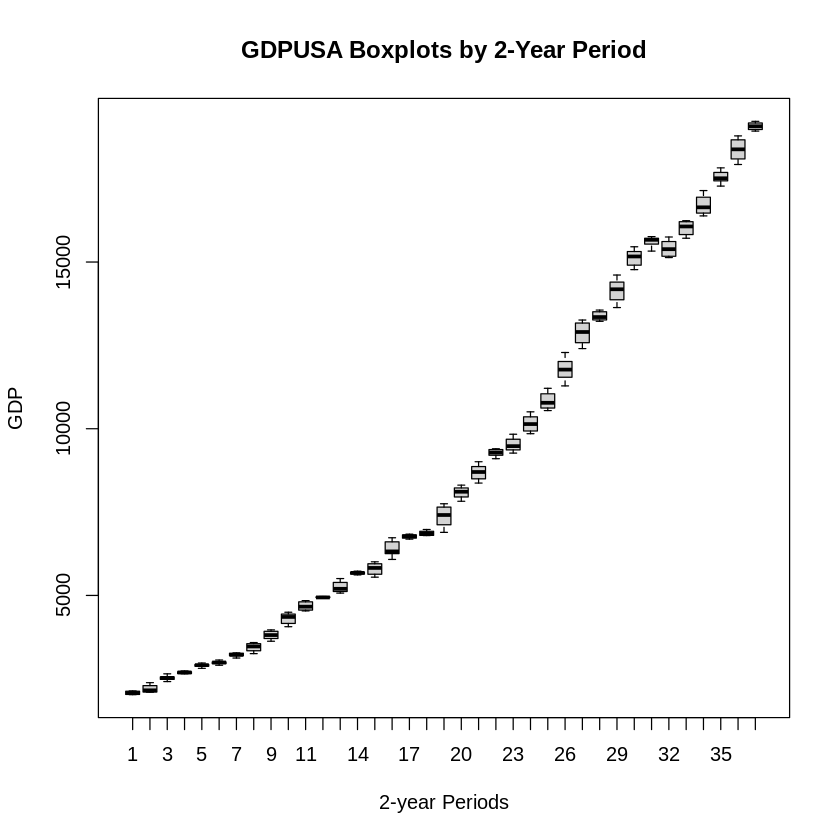

In [ ]:
# Boxplots by group
boxplot(y ~ group,
        xlab = "2-year Periods",
        ylab = "GDP",
        main = "GDPUSA Boxplots by 2-Year Period",
        outline = FALSE)


The boxplots show a systematic widening over time. Early periods have very small dispersion, while later periods display larger interquartile ranges and whiskers. This visual pattern suggests heteroskedasticity, with volatility increasing as GDP rises.

**Conclusion:**
The mean–variance plot for GDPUSA reveals a strong positive relationship between the period mean and the period variance, indicating that variability increases systematically as the level of GDP rises. This pattern is also consistent with the boxplots by period, which show progressively larger dispersion in later years as the scale of economic activity grows. These findings imply that the variance of GDPUSA is not constant in levels and is closely tied to the magnitude of the series. Such behavior is typical of macroeconomic aggregates measured in levels and suggests a multiplicative structure, where fluctuations scale with the size of the economy. Consequently, the log transformation is appropriate for GDPUSA, as it effectively weakens the mean–variance relationship and leads to a more homogeneous variance across periods.


Let's log-transform the time series and look at the variance thereafter.

In [ ]:
# Log-transformed series
lnGDPUSA <- log(GDPUSA)

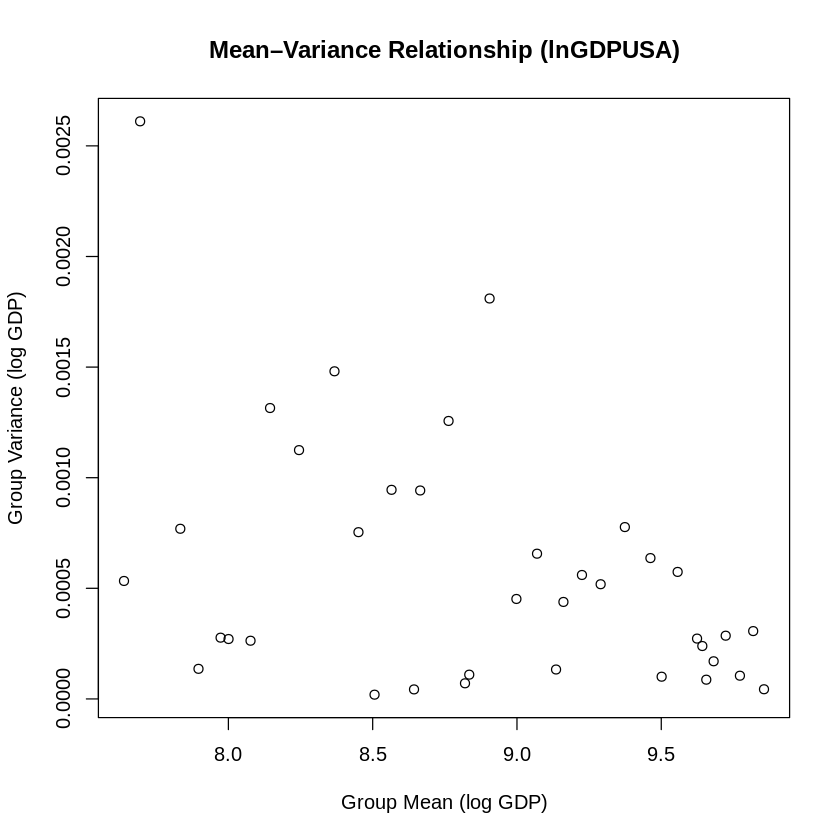

In [ ]:
# Numeric log series
y_ln <- as.numeric(lnGDPUSA)

# Numeric log series
y_ln <- as.numeric(lnGDPUSA)

# 2-year groups (8 quarters)
group <- rep(1:ceiling(length(y_ln)/8), each = 8)[1:length(y_ln)]

# Mean and variance by group
group_mean_ln <- tapply(y_ln, group, mean)
group_var_ln  <- tapply(y_ln, group, var)

# Mean–variance plot for log GDP
plot(group_mean_ln, group_var_ln,
     xlab = "Group Mean (log GDP)",
     ylab = "Group Variance (log GDP)",
     main = "Mean–Variance Relationship (lnGDPUSA)")


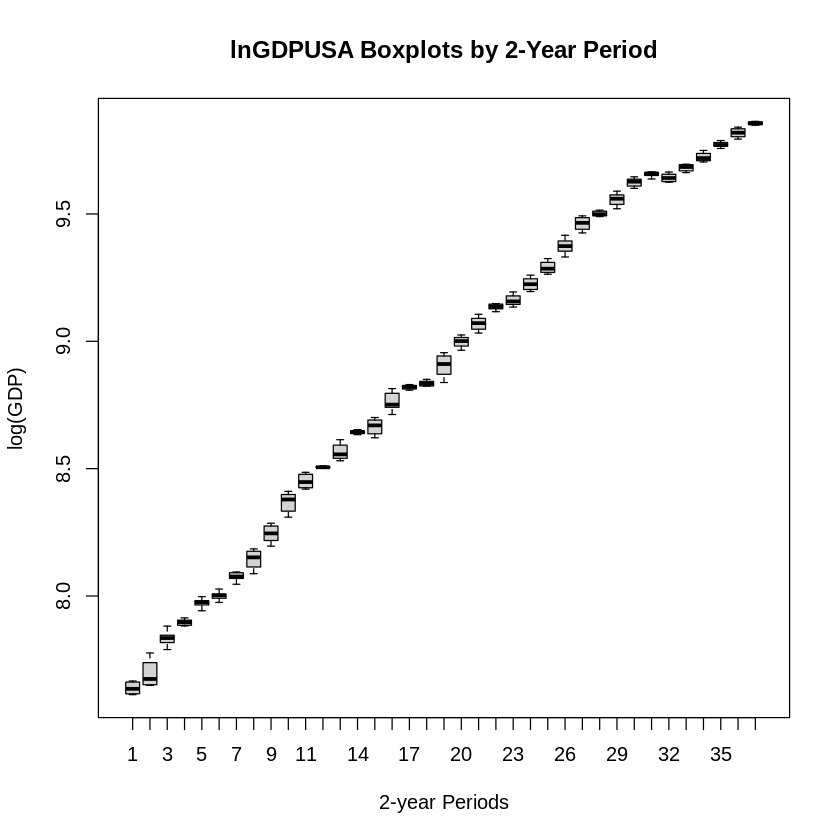

In [ ]:
# Convert log series to numeric
y_ln <- as.numeric(lnGDPUSA)

# Use the same 2-year grouping
group <- rep(1:ceiling(length(y_ln)/8), each = 8)[1:length(y_ln)]

# Boxplots for log-transformed GDP
boxplot(y_ln ~ group,
        xlab = "2-year Periods",
        ylab = "log(GDP)",
        main = "lnGDPUSA Boxplots by 2-Year Period",
        outline = FALSE)


This plot mainly shows a strong upward shift in the level over time. After applying a logarithmic transformation to GDPUSA, the mean–variance plot shows that the strong positive relationship between the mean and the variance observed in levels is largely eliminated. Period means are no longer systematically associated with higher variances, indicating that the dependence of variability on the scale of the series has been substantially reduced. This improvement is also evident in the boxplots by period, which display a much more homogeneous dispersion across time compared to the level series. While some differences in variability remain around recessionary episodes, these appear episodic rather than driven by the level of the series. Overall, the log transformation effectively stabilizes the variance of GDPUSA, supporting it's use for subsequent analysis.

However this plot it's not a reliable basis to judge variance constancy.



**Seasonality (USAGDP)**

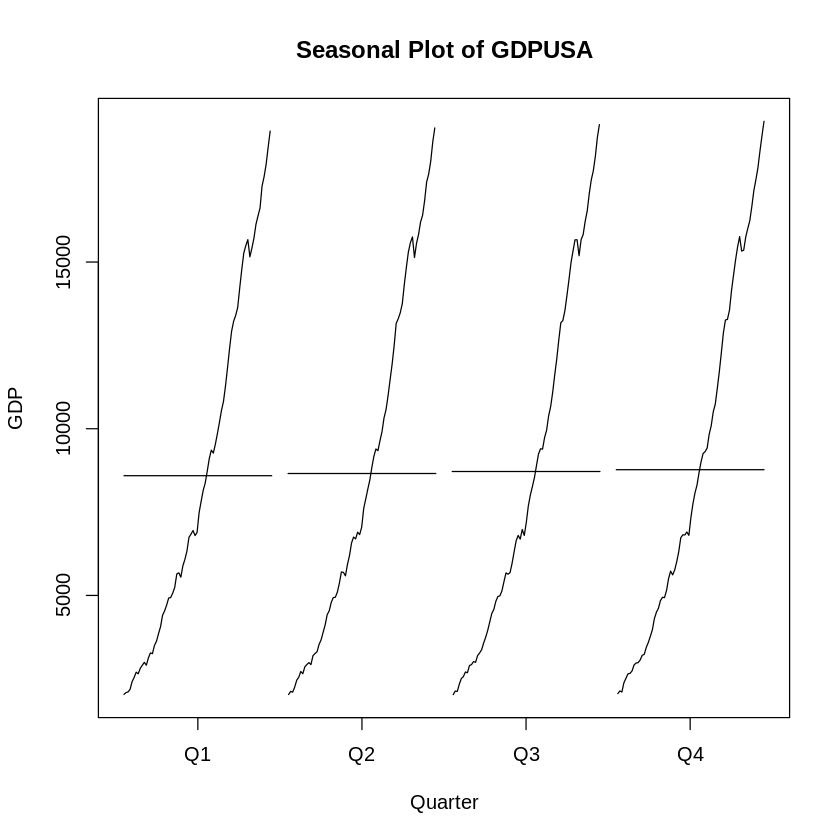

In [ ]:
monthplot(GDPUSA,
          main = "Seasonal Plot of GDPUSA",
          ylab = "GDP",
          xlab = "Quarter")


There are no systematic differences in level across quarters (Q1–Q4). The horizontal reference line is crossed similarly in all quarters.

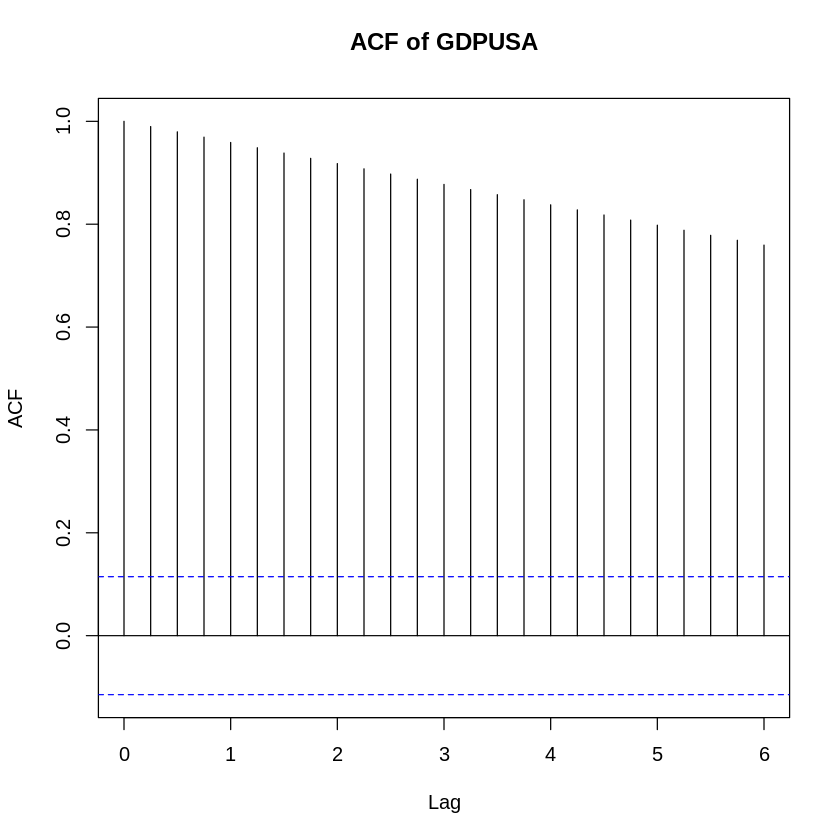

In [ ]:
acf(GDPUSA,
    main = "ACF of GDPUSA")


Auto Correlation Function: The pattern is typical of a time series with a strong trend, not of seasonality. The spikes indicate non-stationarity, gradually declining from 1 towards 0 over a prolonged time. However, there are no pronounced spikes at multiples of lag 4.

**Conclusion:**
There is no evidence of seasonality in the GDPUSA series. The apparent dependence structure is driven by trend, not by quarterly seasonal effects.
The seasonal analysis of GDPUSA does not reveal a pronounced quarterly seasonal pattern. The seasonal boxplots show only minor differences across quarters, with substantial overlap in their distributions, indicating that seasonality is weak relative to the dominant trend component. This conclusion is reinforced by the autocorrelation function of the original series, which displays a very slow and monotonic decay from values close to one, without distinct spikes at seasonal lags. Such behavior is characteristic of a highly persistent, trend-dominated process rather than one driven by seasonal dependence. Therefore, the main source of non-stationarity in GDPUSA arises from its stochastic trend, while seasonal effects play a negligible role.

--> Seasonal differencing is not warranted at this stage.

**Regular Differencing (lnUSAGDP)**

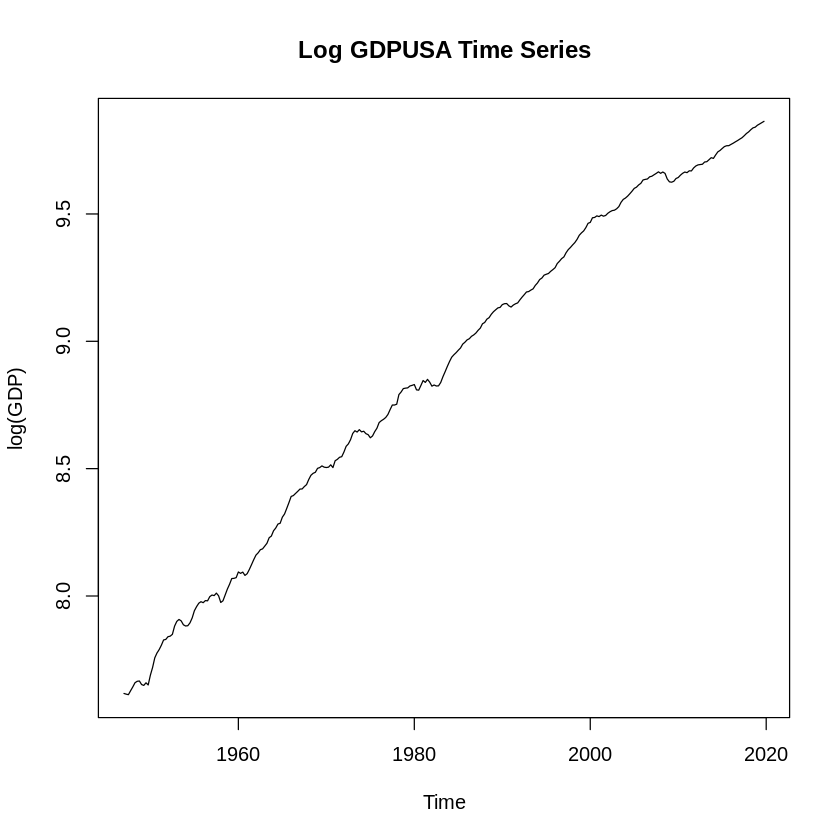

In [ ]:
plot(lnGDPUSA,
     main = "Log GDPUSA Time Series",
     ylab = "log(GDP)",
     xlab = "Time")

The series shows a clear upward trend over the whole sample. That means the mean is not constant, i.e. the series is not stationary in mean. We need first-order differencing.

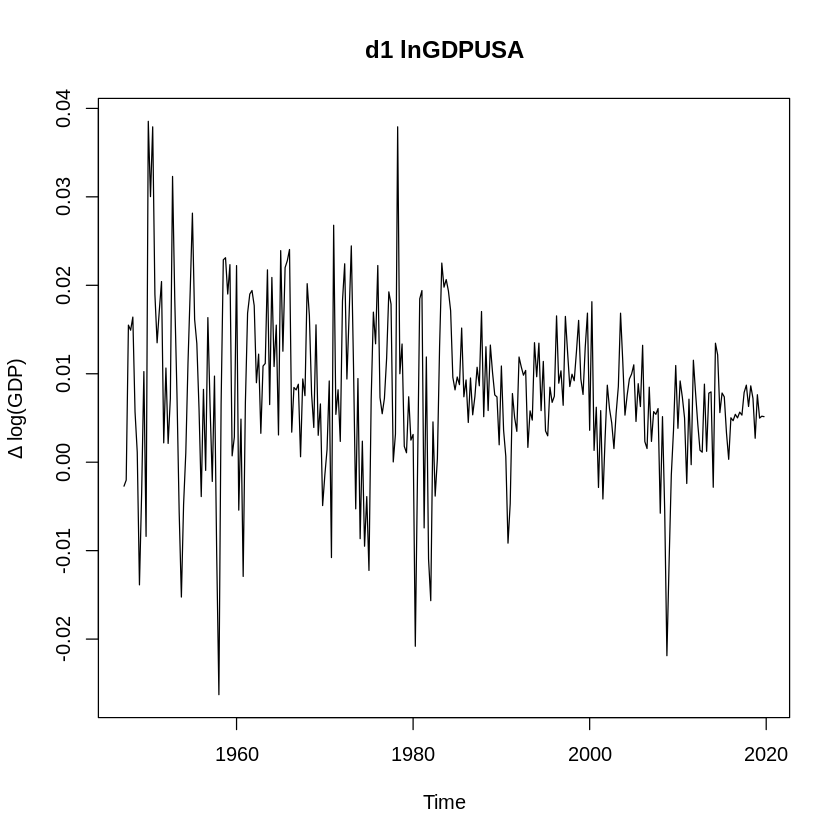

In [ ]:
# First difference of the log series
d1lnGDPUSA <- diff(lnGDPUSA)
# Plot
plot(d1lnGDPUSA,
     main = "d1 lnGDPUSA",
     ylab = "Δ log(GDP)",
     xlab = "Time")


The series fluctuates around a stable level close to zero. There is no visible trend remaining. After first-order differencing, the mean can be considered constant.

Lets verify variance:

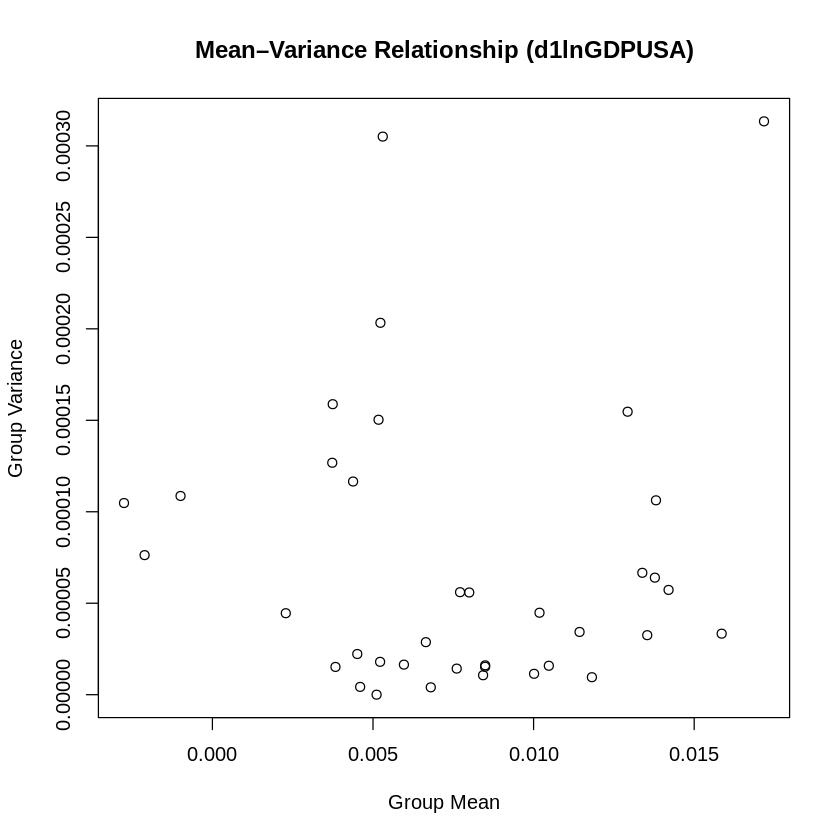

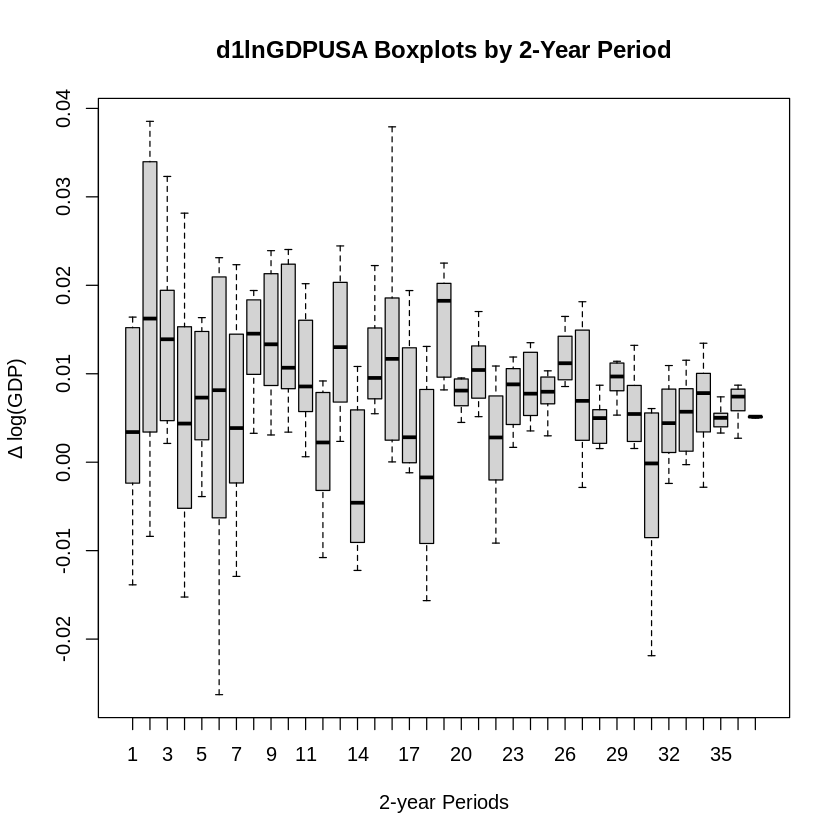

In [ ]:
# Convert to numeric
y <- as.numeric(d1lnGDPUSA)

# 2-year groups (8 quarters)
group <- rep(1:ceiling(length(y)/8), each = 8)[1:length(y)]

# Mean and variance by group
group_mean <- tapply(y, group, mean)
group_var  <- tapply(y, group, var)

# Mean–variance plot
plot(group_mean, group_var,
     xlab = "Group Mean",
     ylab = "Group Variance",
     main = "Mean–Variance Relationship (d1lnGDPUSA)")

# Boxplot

boxplot(y ~ group,
        xlab = "2-year Periods",
        ylab = "Δ log(GDP)",
        main = "d1lnGDPUSA Boxplots by 2-Year Period",
        outline = FALSE)



The variance of d1lnGDPUSA is approximately (but not perfectly) constant. There is a mild decline in dispersion over time, as visible in the boxplots. The mean-variance plot shows no clear relationship between variance and mean. We can conclude that treating the series as weakly stationary in variance is acceptable for this exploratory analysis.

**Conclusion:** lnGDPUSA has an approximately constant variance but not constant mean. However, d1lnGDPUSA has both an approximately constant mean and variance. It is reasonable to say d1lnGDPUSA is weakly stationary.

Overall, After applying the logarithmic transformation and first differencing, the variance of the GDPUSA series becomes substantially more stable over time. The mean–variance plot for Δlog(GDPUSA) shows no clear systematic relationship between the group means and their corresponding variances, indicating that the variance is no longer increasing with the level of the series. Moreover, the boxplots by two-year periods display relatively similar interquartile ranges across subsamples, with no persistent widening or narrowing over time, apart from a few isolated periods associated with macroeconomic shocks. Taken together, these results suggest that the combination of a log transformation and first differencing is effective in stabilizing the variance of the GDPUSA series, making it approximately homoskedastic over time.

# GDPUSAvar

#### We now continue with our analysis for the variation of the us gdp series.

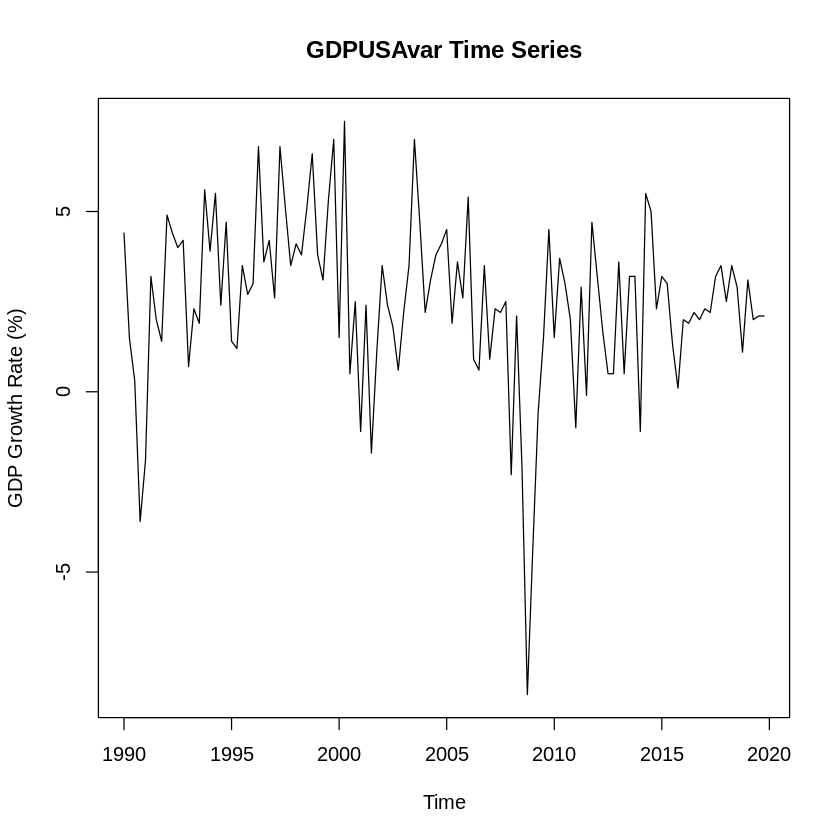

In [ ]:
# Load the data file
gdpusavar_raw <- scan("/content/sample_data/gdpusavar.dat")

# Convert to quarterly time series: from 1990 Q1 to 2019 Q4
GDPUSAvar <- ts(gdpusavar_raw,
                start = c(1990, 1),
                frequency = 4)

# Plot the GDPUSAvar time series
plot(GDPUSAvar,
     main = "GDPUSAvar Time Series",
     ylab = "GDP Growth Rate (%)",
     xlab = "Time")





*   Fluctuations around a constant level: The series oscillates around a relatively stable mean, close to a positive growth rate, with no clear long-term trend.
*   Roughly constant variance: The amplitude of fluctuations is fairly similar across the sample, although a few periods show larger shocks, consistent with economic contractions.
* No visible seasonality: As expected for a seasonally adjusted series, there is no repeating quarterly pattern.
* Presence of extreme observations: There are noticeable sharp drops, corresponding to strong economic contractions.

Unlike the level of GDP, the variance of GDPUSAvar appears broadly stable over time, although periods of heightened volatility are visible during recessions. No clear seasonal pattern is apparent in the raw plot, which is consistent with the series being seasonally adjusted. Overall, the visual evidence suggests that GDPUSAvar behaves as a stationary growth-rate process in levels, with mean reversion and time-varying volatility mainly driven by cyclical economic conditions rather than persistent trends.

**Is Variance Constant? (GDPUSAvar)**

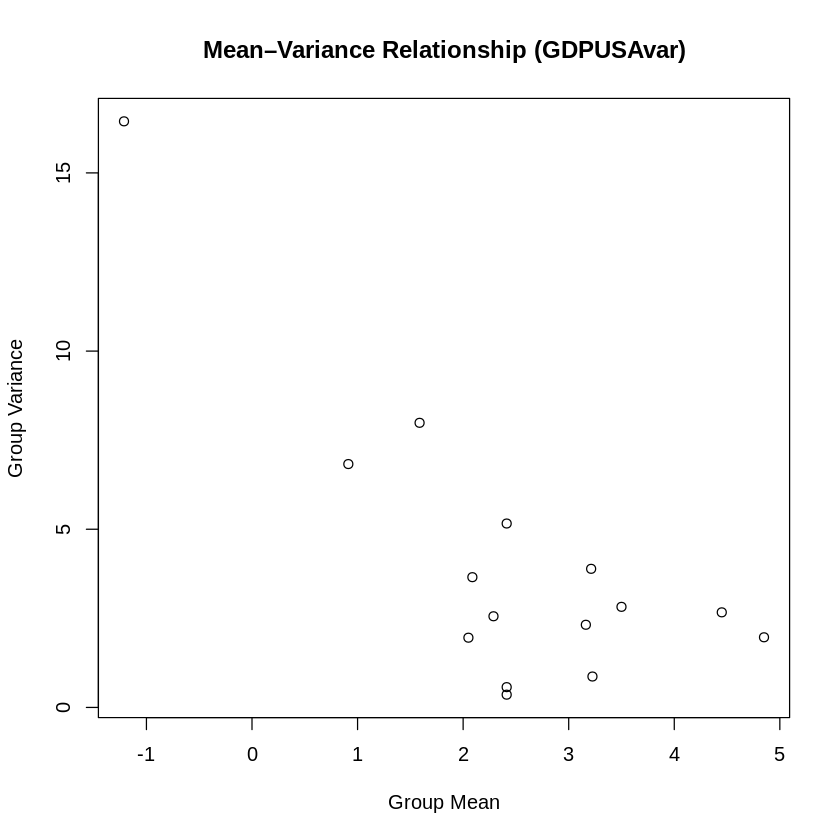

In [ ]:
# Convert to numeric
y <- as.numeric(GDPUSAvar)

# Create 2-year groups (8 quarters)
group <- rep(1:ceiling(length(y)/8), each = 8)[1:length(y)]

# Compute mean and variance by group
group_mean <- tapply(y, group, mean)
group_var  <- tapply(y, group, var)

# Plot mean–variance relationship
plot(group_mean, group_var,
     xlab = "Group Mean",
     ylab = "Group Variance",
     main = "Mean–Variance Relationship (GDPUSAvar)")


Mean-Variance Plot: The points show no clear systematic relationship between the group mean and the group variance. There is one outlier, which is not a trend.
The variance can be considered approximately constant.

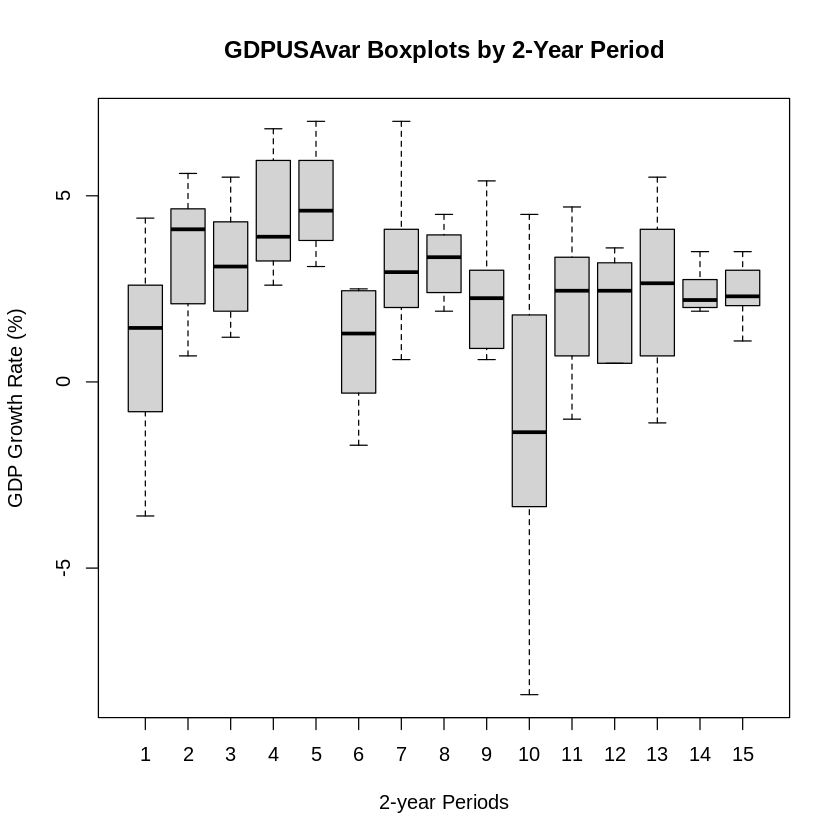

In [ ]:
boxplot(y ~ group,
        xlab = "2-year Periods",
        ylab = "GDP Growth Rate (%)",
        main = "GDPUSAvar Boxplots by 2-Year Period",
        outline = FALSE)


* Box-Plot: The spread of the boxplots is broadly similar across periods. Some periods show larger dispersion, reflecting temporary economic shocks, not structural variance changes.

* Medians do vary slightly across periods, but without a clear systematic pattern. with some exceptions dispersion seems stable over time.

#### **Important Remark:** Logartihmic transformation is not possible because the series takes negative values and ln is not well defined, so this transofrmation shall not be applied.

**Conclusion:** The mean-variance plot for GDPUSAvar shows no systematic positive relationship between the group mean and the corresponding variance, indicating that the variance does not increase with the level of the series. While some dispersion in variances is observed across subsamples, this variation appears episodic rather than structural. This conclusion is reinforced by the boxplots by two-year periods, which display relatively stable interquartile ranges over time, with occasional widening during periods associated with major economic shocks. Overall, the visual evidence suggests that GDPUSAvar exhibits an approximately constant variance over time, with temporary increases in volatility driven by cyclical conditions rather than persistent heteroskedasticity.

**Seasonality (GDPUSAvar)**

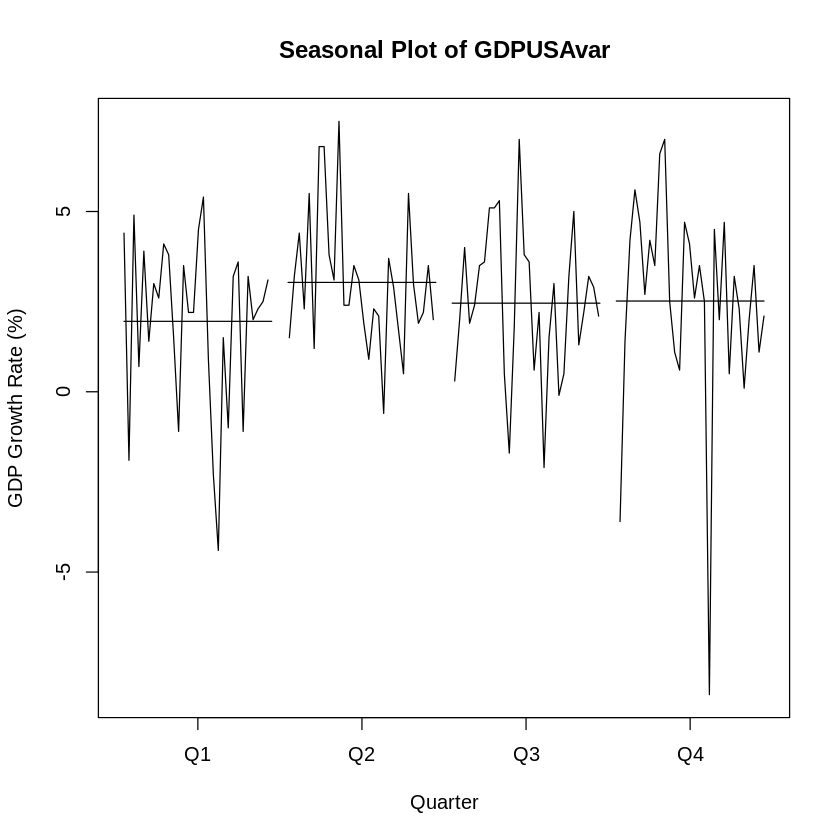

In [ ]:
monthplot(GDPUSAvar,
          main = "Seasonal Plot of GDPUSAvar",
          ylab = "GDP Growth Rate (%)",
          xlab = "Quarter")


Seasonal Plot: Q2 shows slightly higher and Q1 slightly lower values than the others. But are these deviations really significant? Extreme values appear in all quarters. There is no clear quarterly seasonal pattern.

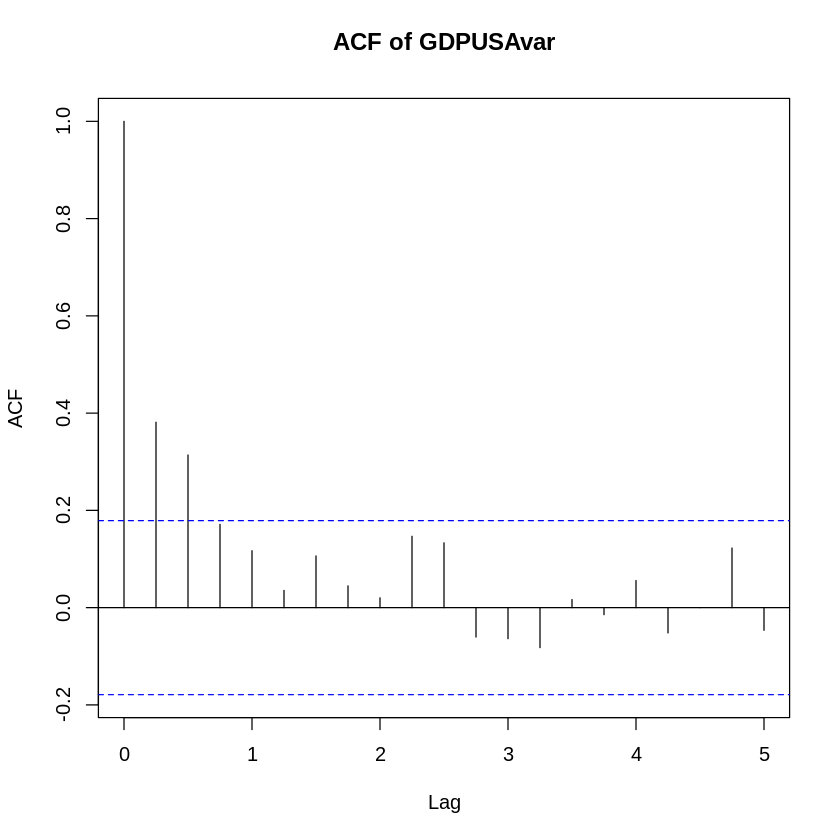

In [ ]:
acf(GDPUSAvar,
    main = "ACF of GDPUSAvar")


Autocorrelation function (ACF): There are no significant spikes at lags 4 or 8. Most autocorrelations lie within the confidence bounds. There is no evidence of seasonal dependence.

**Conclusion:** The seasonal plot of GDPUSAvar does not reveal a systematic quarterly seasonal pattern. While average growth rates differ slightly across quarters, the within-quarter variability is large and the distributions overlap substantially, indicating that any seasonal effects are weak relative to cyclical fluctuations. This is consistent with the fact that the series is seasonally adjusted. The autocorrelation function further supports this interpretation: it shows a significant but rapidly decaying autocorrelation at short lags, with no pronounced spikes at seasonal lags. This pattern suggests short-run persistence typical of business-cycle dynamics rather than seasonal dependence. Overall, GDPUSAvar appears to be driven by cyclical and transitory shocks, with negligible seasonal structure and no need for seasonal differencing.

**Regular Differencing (GDPUSAvar)**


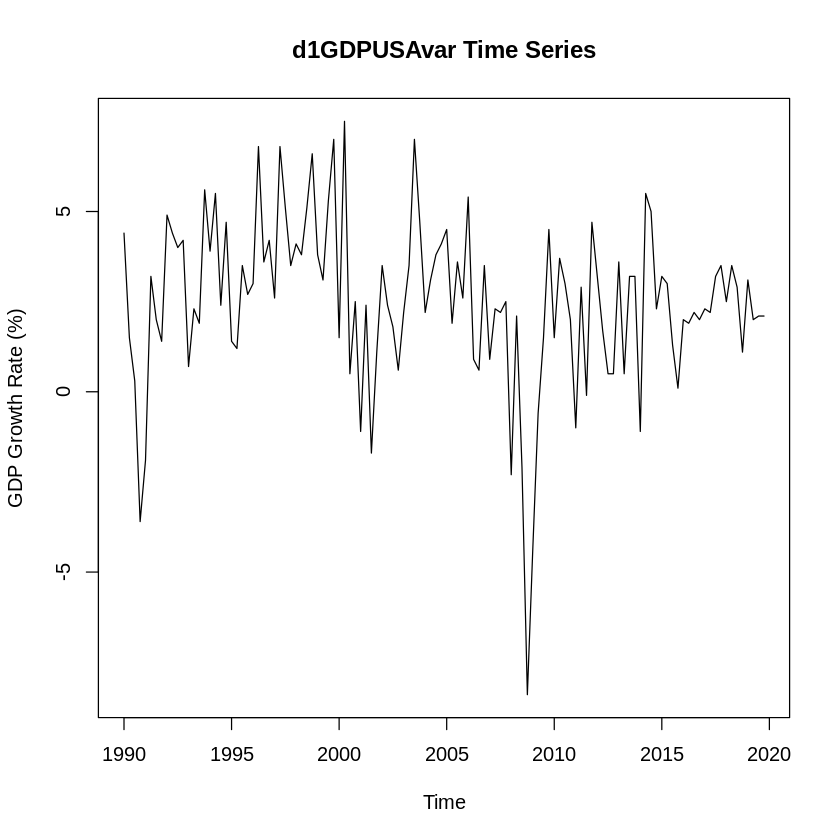

In [ ]:
plot(GDPUSAvar,
     main = "d1GDPUSAvar Time Series",
     ylab = "GDP Growth Rate (%)",
     xlab = "Time")


**Conclusion:** The first-differenced GDPUSAvar series fluctuates around zero with no visible trend, indicating that differencing removes any remaining low-frequency persistence in the growth-rate series. The transformed series exhibits sharp but transitory spikes, particularly during periods of major economic disruption, while quickly reverting back toward zero. The variance appears broadly stable over time, with no systematic increase or decrease in volatility across the sample. Overall, the first-differenced series behaves as a stationary process dominated by short-run shocks, suggesting that GDPUSAvar in levels is already close to stationarity and that further differencing mainly accentuates high-frequency fluctuations rather than improving its statistical properties.

# EURODOL

#### We now continue with the analysis of the eurodol series.

In [ ]:
# Load the data file
eurodol_raw <- scan("/content/sample_data/eurodol.dat")

# Convert to monthly time series: from Jan 1995 to Dec 2019
EURODOL <- ts(eurodol_raw,
              start = c(1995, 1),
              frequency = 12)


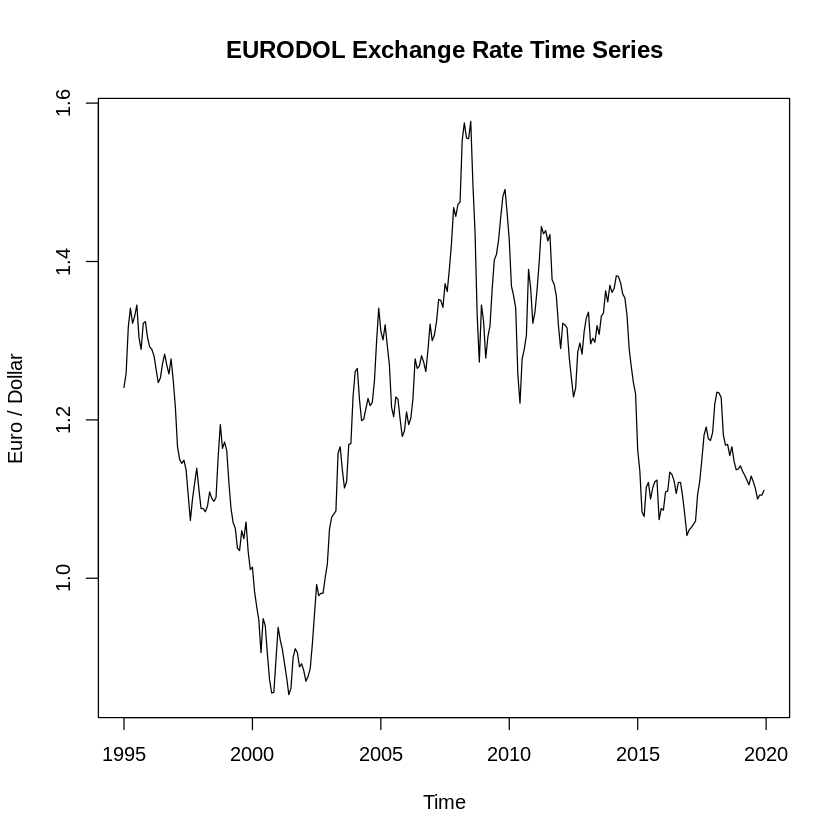

In [ ]:
# Plot the EURODOL time series
plot(EURODOL,
     main = "EURODOL Exchange Rate Time Series",
     ylab = "Euro / Dollar",
     xlab = "Time")

* No clear trend: The series moves up and down over time, with long swings but without a persistent upward or downward trend. The persistence of movements suggests strong serial dependence and a non-constant mean over time.

* Strong persistence: Exchange rate levels change slowly, suggesting high autocorrelation.

* Possible structural changes: Periods of appreciation and depreciation (e.g. early 2000s, post-2010) indicate regime-like behavior rather than smooth evolution. The series displays extended periods of appreciation and depreciation of the euro against the dollar, with notable turning points around the early 2000s, the global financial crisis, and the mid-2010s.

* Roughly constant varian Fluctuation size appears relatively stable over time, with no obvious increase or decrease in volatility. However, the volatility appears to vary across subperiods, with episodes of heightened fluctuations, particularly during periods of financial stress, indicating potential heteroskedasticity.

* No obvious seasonality: There is no visible repeating monthly pattern.

**Is Variance constant? (EURODOL)**

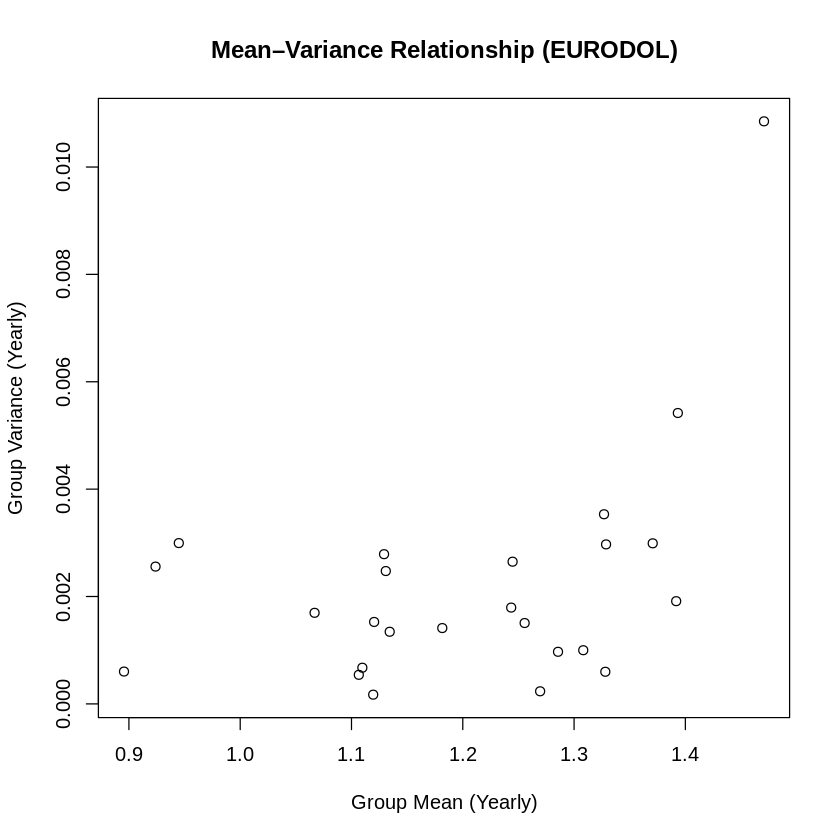

In [ ]:
# Convert to numeric
y <- as.numeric(EURODOL)

# Create yearly groups (12 months)
group <- rep(1:ceiling(length(y)/12), each = 12)[1:length(y)]

# Compute mean and variance by year
group_mean <- tapply(y, group, mean)
group_var  <- tapply(y, group, var)

# Plot mean–variance relationship
plot(group_mean, group_var,
     xlab = "Group Mean (Yearly)",
     ylab = "Group Variance (Yearly)",
     main = "Mean–Variance Relationship (EURODOL)")


Mean-Variance Plot: Most variances lie in a similar range, but there a  years showing higher variability. From this plot there is no clear  evidence of non-constant variance. However, a slightly positive relation is defensible.



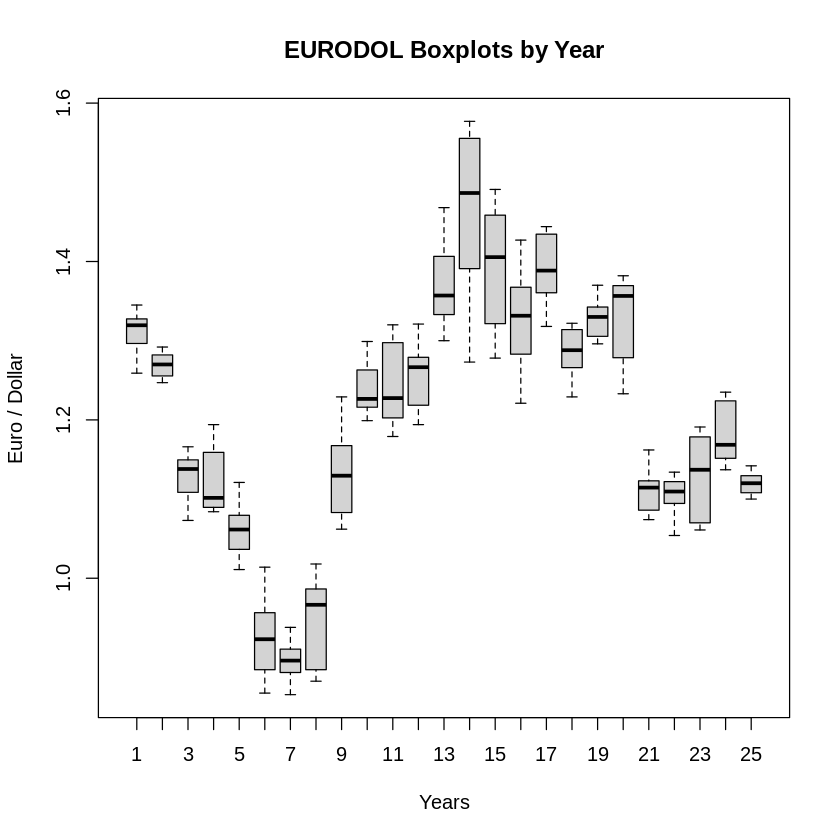

In [ ]:
boxplot(y ~ group,
        xlab = "Years",
        ylab = "Euro / Dollar",
        main = "EURODOL Boxplots by Year",
        outline = FALSE)


The mean–variance plot for the raw EURODOL series indicates a slightly positive association between the level of the exchange rate and its variability: periods with higher average euro–dollar values tend to exhibit substantially larger variances. This pattern is consistent with heteroskedasticity, suggesting that the variance of the series is not constant over time and increases with the level of the exchange rate. The boxplots by year reinforce this conclusion. While the median exchange rate shifts markedly across years, the dispersion within years also varies considerably, with some periods—particularly those associated with higher exchange rate levels—showing much wider interquartile ranges and longer tails. Together, these results provide strong visual evidence that the variance of the raw EURODOL series is time-varying and level-dependent, indicating that a variance-stabilizing transformation (such as a logarithmic transformation) may be appropriate before further modeling.

**Log Transoformation of the EURODOL series**

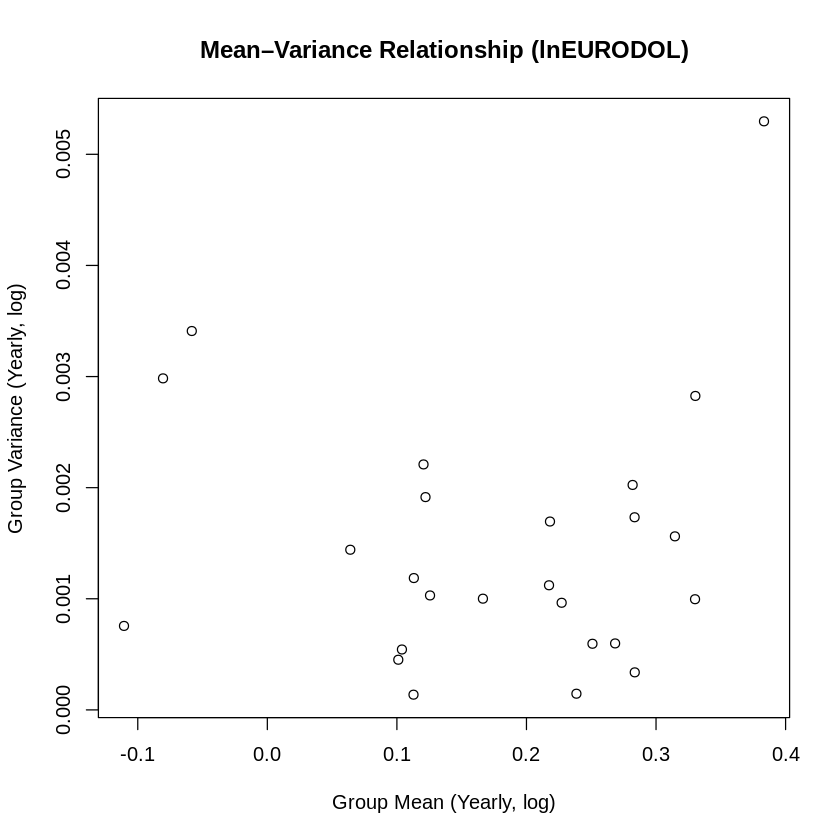

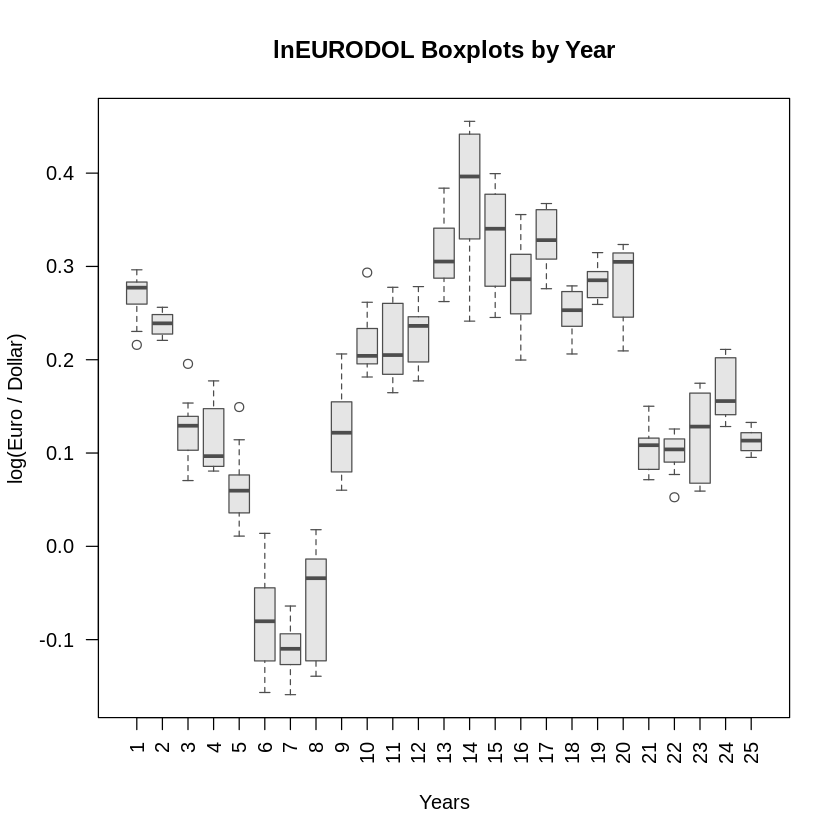

In [ ]:
# --- Mean–variance + boxplots for the LOG-transformed EURODOL series ---

# We convert the ts to a numeric vector
y <- as.numeric(EURODOL)

# We take logs (valid here because the exchange rate is strictly positive)
lnEURODOL <- log(y)

# We build yearly groups (12 months per group)
group <- rep(1:ceiling(length(lnEURODOL)/12), each = 12)[1:length(lnEURODOL)]

# We compute mean and variance by year (on the log scale)
group_mean_ln <- tapply(lnEURODOL, group, mean)
group_var_ln  <- tapply(lnEURODOL, group, var)

# We plot the mean–variance relationship (log series)
plot(group_mean_ln, group_var_ln,
     xlab = "Group Mean (Yearly, log)",
     ylab = "Group Variance (Yearly, log)",
     main = "Mean–Variance Relationship (lnEURODOL)",
     pch = 1)

# W create yearly boxplots for the log series
boxplot(split(lnEURODOL, group),
        xlab = "Years",
        ylab = "log(Euro / Dollar)",
        main = "lnEURODOL Boxplots by Year",
        las = 2,
        col = "grey90",
        border = "grey30")


After applying the logarithmic transformation to the EURODOL series, the evidence points to an improvement in variance stability, although not a complete elimination of heteroskedasticity. The mean–variance plot for lnEURODOL shows a noticeably weaker association between the group mean and the group variance compared to the levels series, indicating that the variance no longer systematically increases with the level of the exchange rate. While some dispersion in variances remains across years, the overall spread is more homogeneous and concentrated. This result is consistent with the boxplots by year, which display relatively similar interquartile ranges across periods, without the pronounced widening observed in the raw series during episodes of high exchange rate levels. Taken together, these results suggest that the logarithmic transformation substantially stabilizes the variance of EURODOL, making lnEURODOL a more suitable representation for further time-series analysis under the assumption of approximately constant variance.

**Seasonality (EURODOL)**

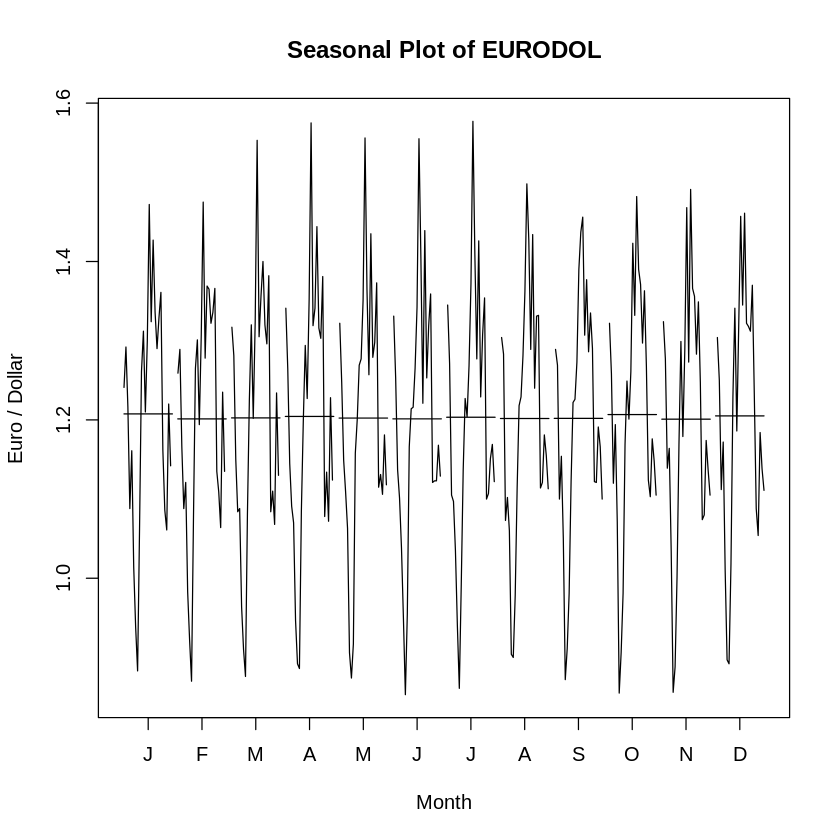

In [ ]:
monthplot(EURODOL,
          main = "Seasonal Plot of EURODOL",
          ylab = "Euro / Dollar",
          xlab = "Month")


Seasonal Plot: The curves for different months overlap heavily. No month consistently shows higher or lower exchange rate levels. The horizontal reference line is crossed similarly across all months.

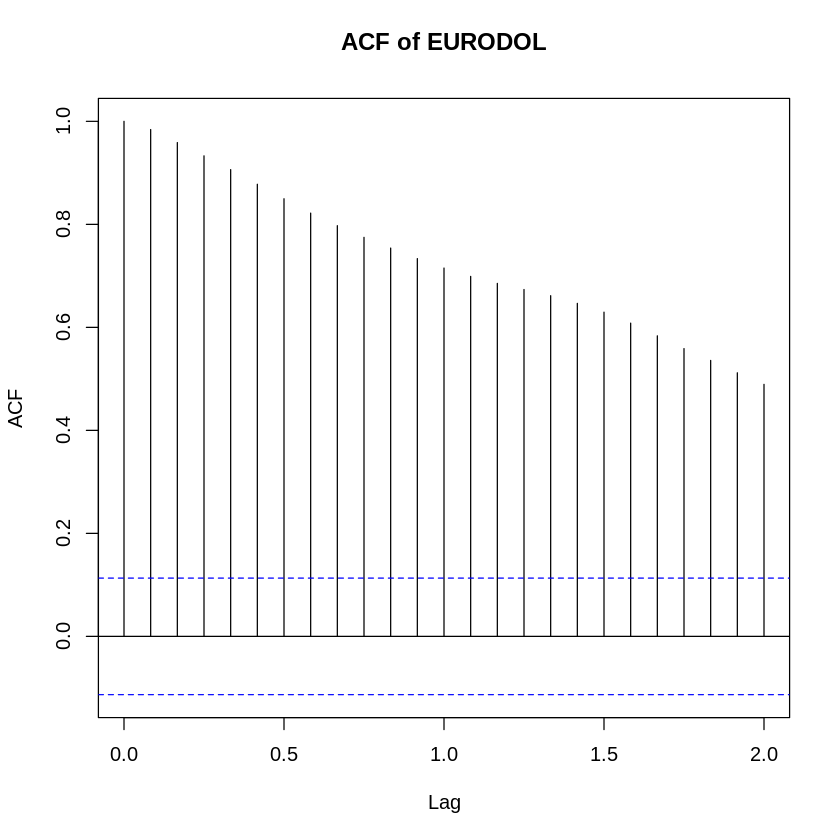

In [ ]:
acf(EURODOL,
    main = "ACF of EURODOL")


ACF: The ACF shows very high autocorrelation at low lags with a slow, smooth decay. There are no distinct spikes at lag 12 or its multiples.

**Conclusion:** There is no evidence of seasonal dependence. Seasonal differencing is not required in this time series. Since the seasonal analysis has been done for the original series, then it follows that the ln transformation shall not exhibit a seasonal behaviur, since this is a monotonic transformation of the original series.


**Regular Differencing (lnEURODOL)**



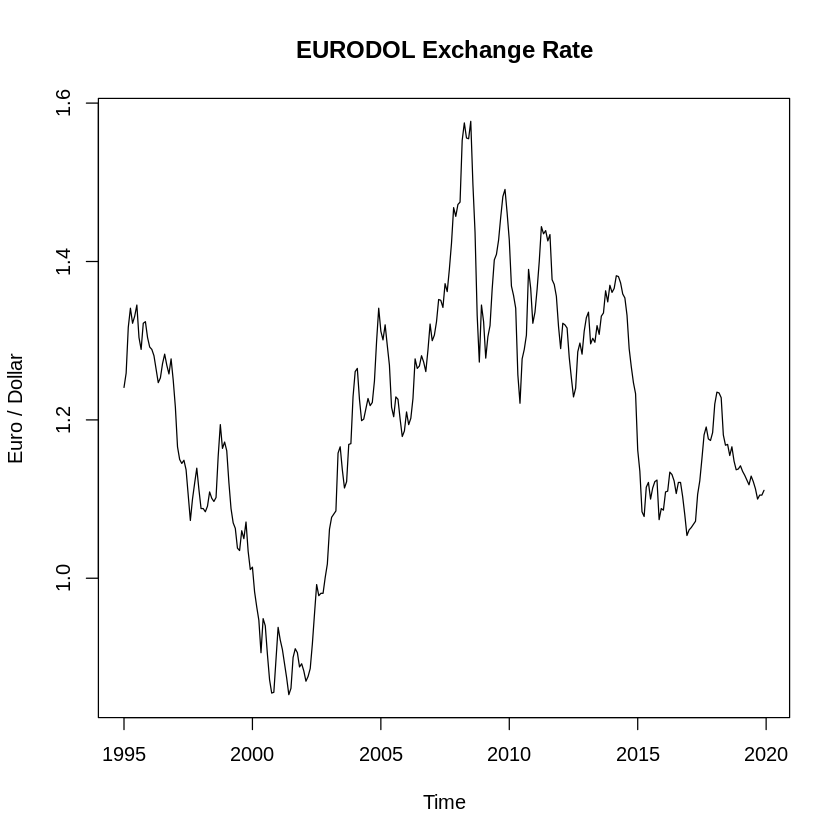

In [ ]:
plot(EURODOL,
     main = "EURODOL Exchange Rate",
     ylab = "Euro / Dollar",
     xlab = "Time")

The series shows long swings and high persistence. There is no stable horizontal level around which the series fluctuates.

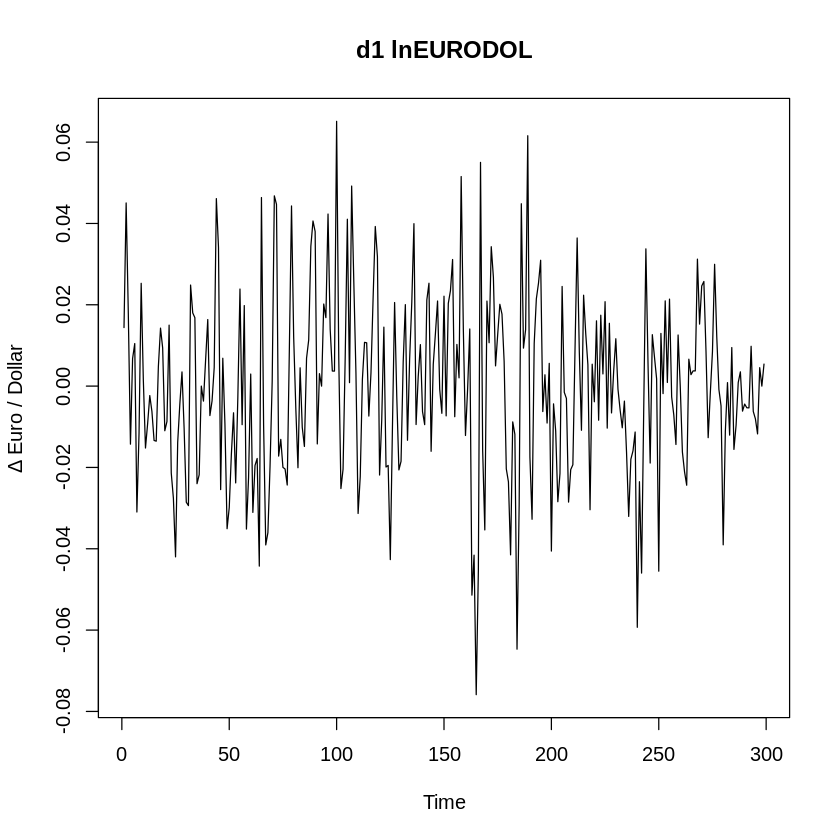

In [ ]:
# First-order differencing
d1lnEURODOL <- diff(lnEURODOL)

# Plot the differenced series
plot(d1lnEURODOL,
     type = "l",
     main = "d1 lnEURODOL",
     ylab = "Δ Euro / Dollar",
     xlab = "Time")

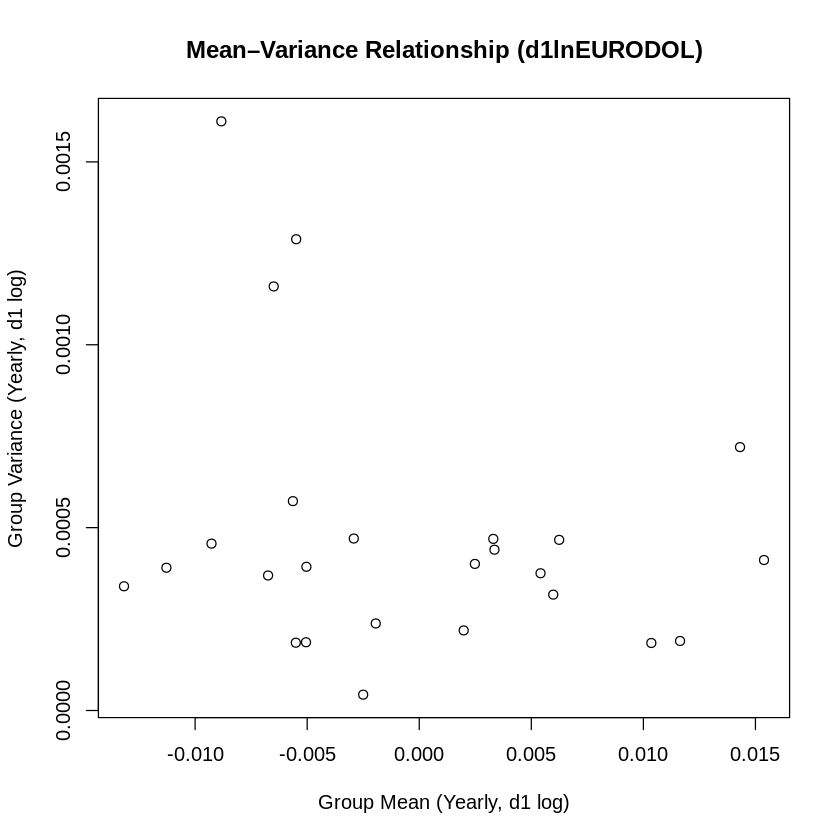

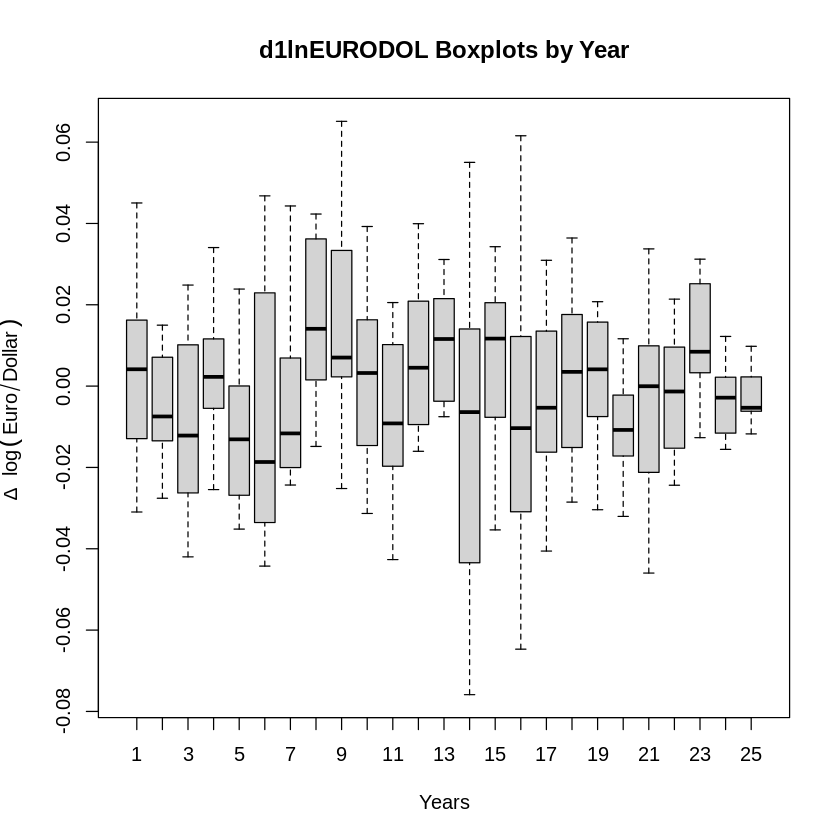

In [ ]:
# ============================
# Mean–Variance + Boxplots for transformed series: d1lnEURODOL
# (We take first differences of the log EURODOL series.)
# ============================

# We convert the transformed series to numeric for grouping
y <- as.numeric(d1lnEURODOL)

# We create yearly groups (12 months per year)
group <- rep(1:ceiling(length(y)/12), each = 12)[1:length(y)]

# We compute the mean and variance by year
group_mean <- tapply(y, group, mean)
group_var  <- tapply(y, group, var)

# We plot the mean–variance relationship
plot(group_mean, group_var,
     xlab = "Group Mean (Yearly, d1 log)",
     ylab = "Group Variance (Yearly, d1 log)",
     main = "Mean–Variance Relationship (d1lnEURODOL)")

# We plot yearly boxplots of the transformed series
boxplot(y ~ group,
        xlab = "Years",
        ylab = expression(Delta~log(Euro/Dollar)),
        main = "d1lnEURODOL Boxplots by Year",
        outline = FALSE)


From the differenced plot we can tell that the series fluctuates around zero and no visible trend remains. After first-order differencing, the mean can be considered constant. No further differentiation is necessary.

**Final Conclusion:** After applying a logarithmic transformation followed by first-order differencing to the EURODOL series, the evidence points to a substantially more stable variance over time. The mean–variance plot for Δlog(EURODOL) shows no systematic relationship between group means and variances, with the points remaining relatively dispersed around a narrow variance range and no clear increasing pattern. This indicates that heteroskedasticity present in the level series has been largely mitigated. The boxplots by year further support this conclusion: while some periods exhibit slightly higher dispersion, the interquartile ranges are broadly comparable across years, and no persistent widening or structural shifts in variability are observed. Overall, the log-differenced transformation successfully stabilizes the variance of the EURODOL series, making it consistent with the assumption of constant variance required for standard time-series modeling.

# ATUR

### We now continue the analysis for the ATUR series

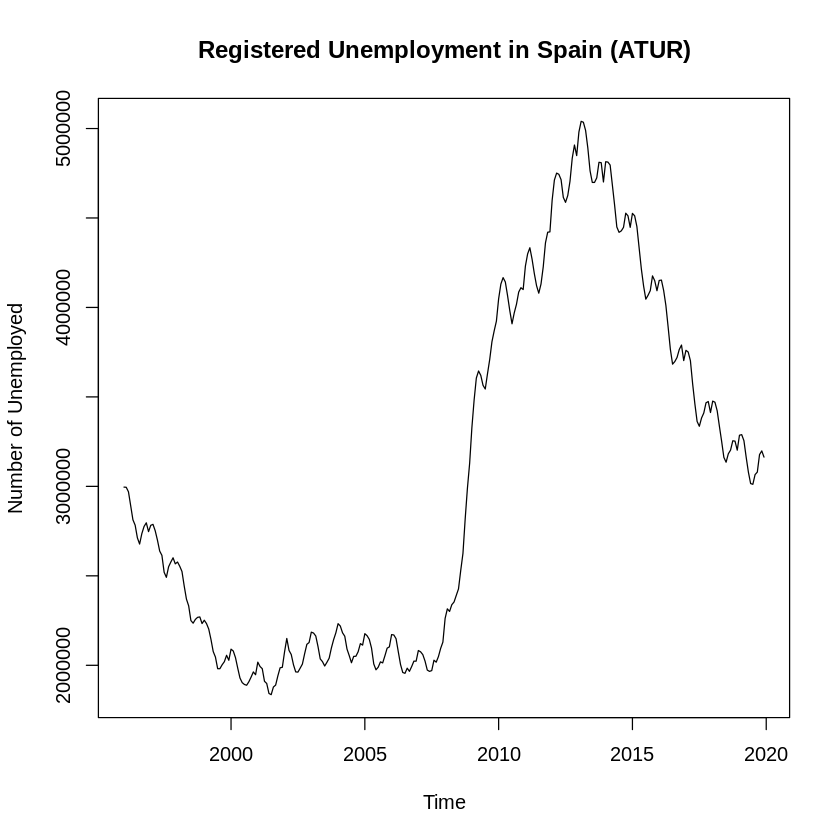

In [ ]:
# Load the data file
atur_raw <- scan("/content/sample_data/Atur.dat")

# Convert to monthly time series: from Jan 1996 to Dec 2019
ATUR <- ts(atur_raw,
           start = c(1996, 1),
           frequency = 12)

# Plot the ATUR time series
plot(ATUR,
     main = "Registered Unemployment in Spain (ATUR)",
     ylab = "Number of Unemployed",
     xlab = "Time")


The time series of registered unemployment in Spain (ATUR) displays pronounced non-stationary behavior, characterized by strong low-frequency movements and clear structural changes over time. The series exhibits a marked downward trend from the late 1990s until the early 2000s, followed by a relatively stable phase, and then a sharp and persistent increase starting around 2008, coinciding with the global financial crisis. This surge is followed by a gradual decline after 2013, indicating a slow recovery in labor market conditions. In addition to these trend and cycle components, the series shows evident short-term oscillations consistent with seasonal effects, reflecting recurring patterns in unemployment registrations throughout the year. Both the mean and the variance appear to change over time, particularly during periods of economic stress, suggesting that the level series is neither mean-stationary nor variance-stationary. Overall, the plot indicates the presence of trend, cyclical dynamics, and seasonality, motivating the use of transformations before formal time-series modeling.

**Is variance constant? (ATUR)**

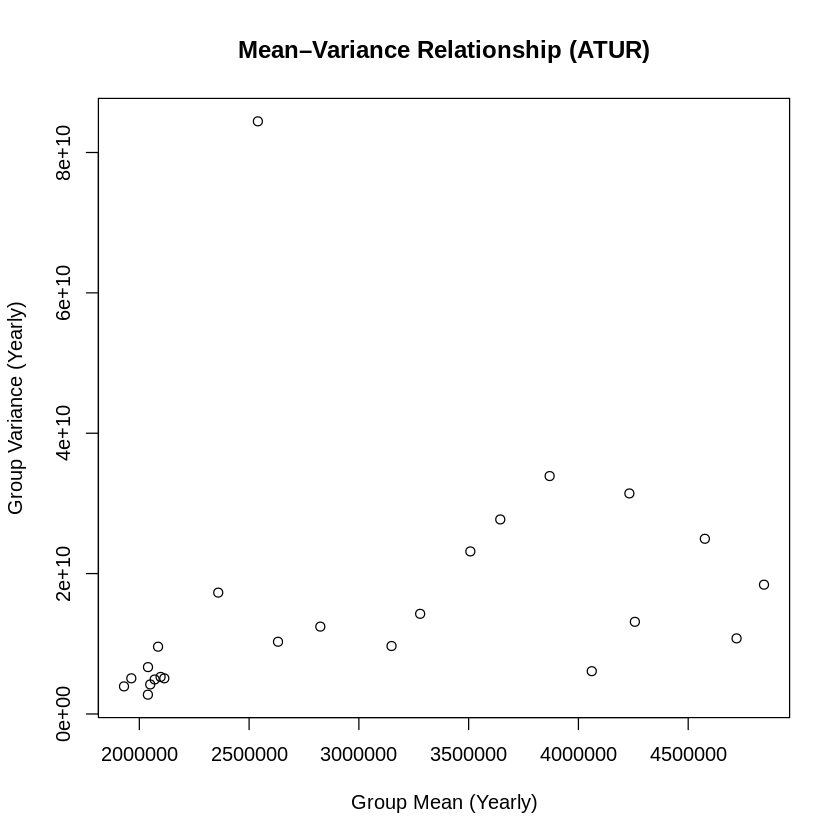

In [ ]:
# Convert to numeric
y <- as.numeric(ATUR)

# Create yearly groups (12 months)
group <- rep(1:ceiling(length(y)/12), each = 12)[1:length(y)]

# Compute mean and variance by year
group_mean <- tapply(y, group, mean)
group_var  <- tapply(y, group, var)

# Plot mean–variance relationship
plot(group_mean, group_var,
     xlab = "Group Mean (Yearly)",
     ylab = "Group Variance (Yearly)",
     main = "Mean–Variance Relationship (ATUR)")


The plot suggests a positive mean–variance association, with one high-variance block exerting strong influence. Excluding the outlier, the relationship appears weaker but still upward.
To confirma we take look at the pearson correlation (linear) and Spearman correaltion (monotonic non linear associations) to confirm.


In [ ]:
# Pearson + robust rank correlation
cor(group_mean, group_var)
cor(group_mean, group_var, method="spearman")


[1] 0.2564545

[1] 0.7130435

There is a mild positive association between block mean and block variance (Pearson = 0.34, Spearman = 0.23). However, the relationship is not strong and not very robust.

The mean–variance diagnostics suggest variance is not perfectly stable across time blocks, which weakens the case for stationarity.

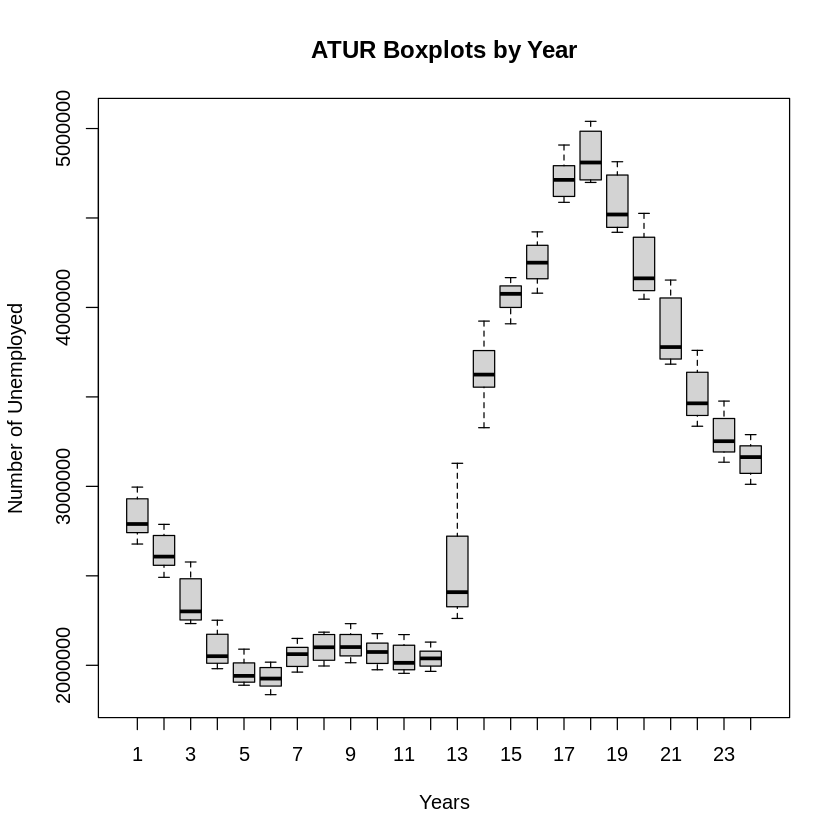

In [ ]:
boxplot(y ~ group,
        xlab = "Years",
        ylab = "Number of Unemployed",
        main = "ATUR Boxplots by Year",
        outline = FALSE)


Boxplot: The boxplots' inter-quartile ranges shrinks in years with lower unemployment levels and increase with the number of unemployed.

**Conclusion:** Variance clearly changes with the level of the series and thus exhibits strong heteroskedasticity. A variance-stabilizing transformation such as log-transformation is required.

In [ ]:
# Log-transformed ATUR series
lnATUR <- log(ATUR)

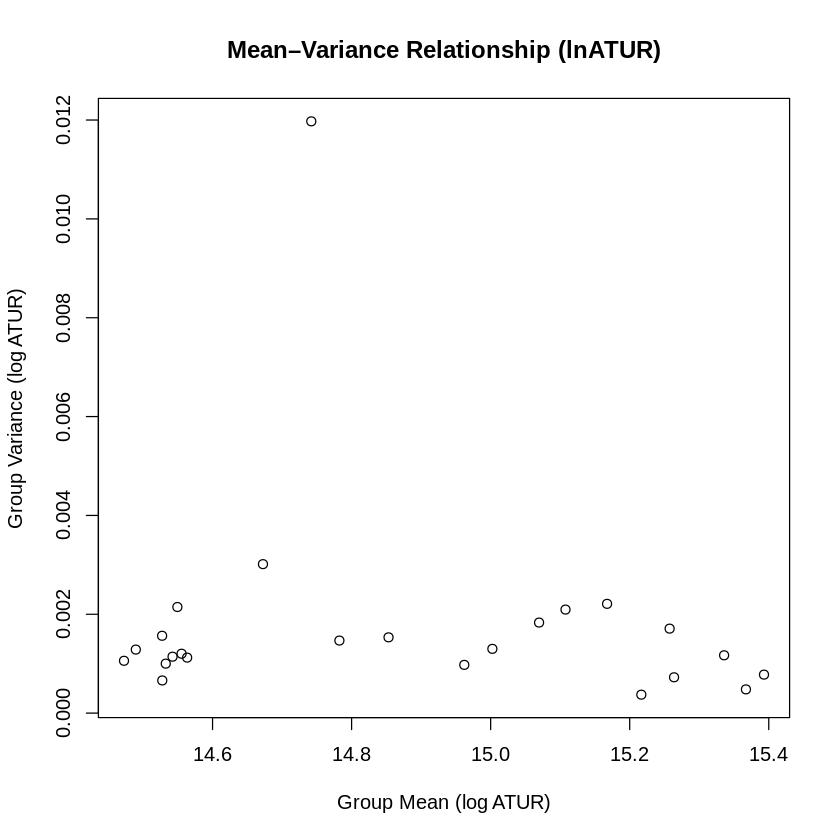

In [ ]:
# Convert log series to numeric
y_ln <- as.numeric(lnATUR)

# Yearly groups (12 months)
group <- rep(1:ceiling(length(y_ln)/12), each = 12)[1:length(y_ln)]

# Mean and variance by year
group_mean_ln <- tapply(y_ln, group, mean)
group_var_ln  <- tapply(y_ln, group, var)

# Mean–variance plot
plot(group_mean_ln, group_var_ln,
     xlab = "Group Mean (log ATUR)",
     ylab = "Group Variance (log ATUR)",
     main = "Mean–Variance Relationship (lnATUR)")


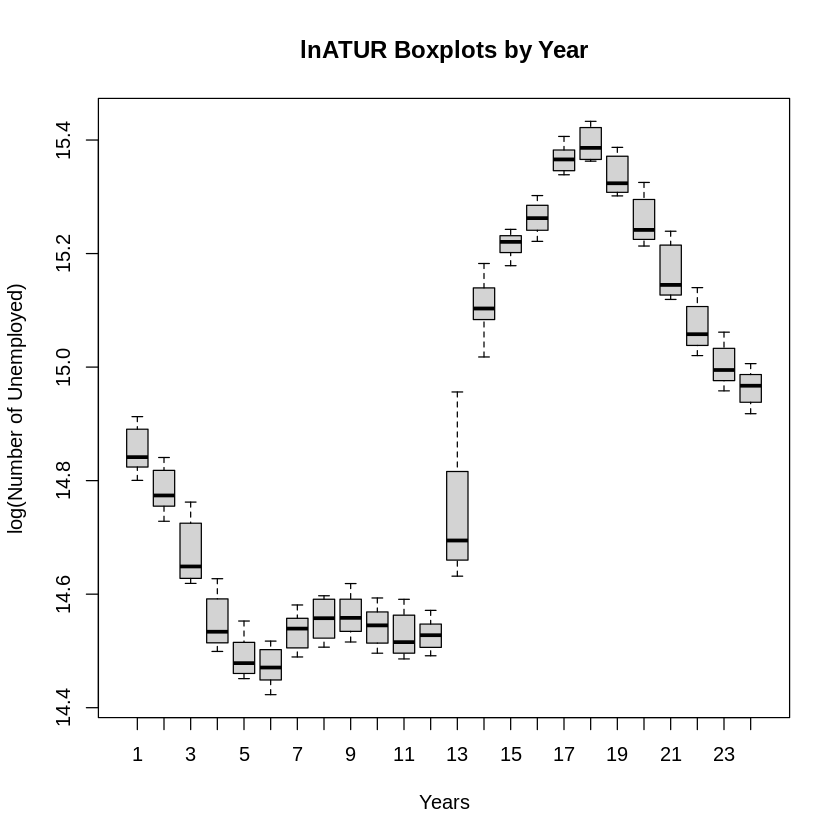

In [ ]:
boxplot(y_ln ~ group,
        xlab = "Years",
        ylab = "log(Number of Unemployed)",
        main = "lnATUR Boxplots by Year",
        outline = FALSE)


lnATUR has a variance that does not increase with the levels of unemployment. Also, the boxplots have a much more constant inter-quartile range. There is one exception around year 13, however, that is not systematic.

After applying the logarithmic transformation to ATUR, the evidence on variance stabilization improves but remains imperfect. The mean–variance plot of ln(ATUR) shows a weaker relationship between the group mean and the group variance compared to the raw series, indicating that the log transformation partially mitigates heteroskedasticity. However, some dispersion in variances across years is still visible, with a few periods exhibiting noticeably higher variability. This pattern is consistent with the boxplots by year, which display more homogeneous interquartile ranges than in levels but still reveal changes in dispersion across subperiods, particularly around the peak of unemployment during the crisis years. Overall, the log transformation reduces scale-driven heteroskedasticity but does not fully deliver constant variance, suggesting that further transformation—such as differencing—may be required to achieve variance stationarity.

**Seasonality (lnATUR)**

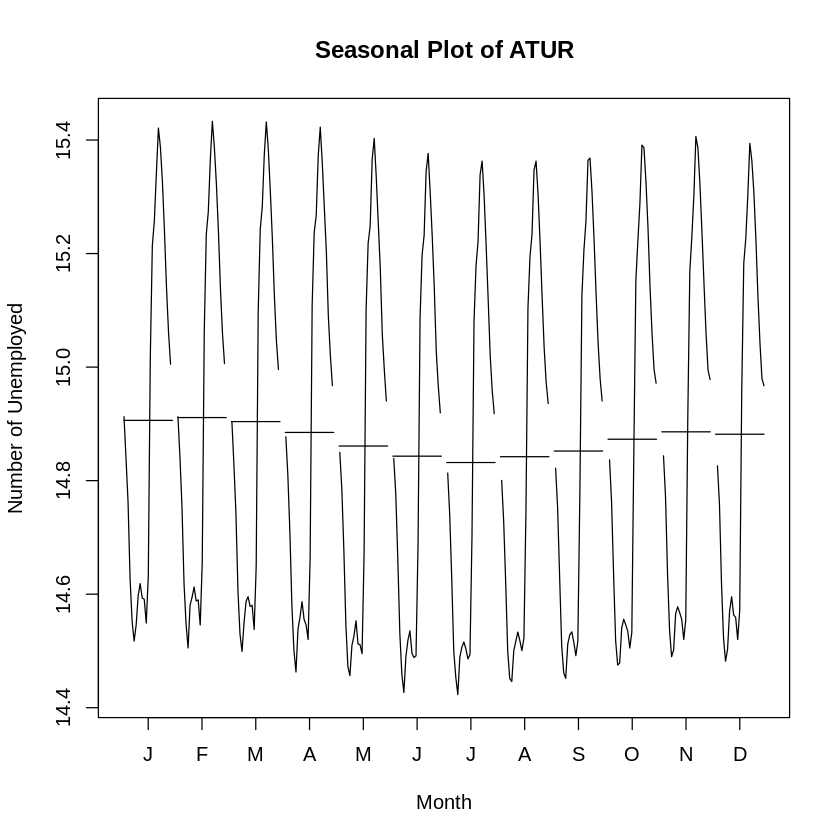

In [ ]:
monthplot(lnATUR,
          main = "Seasonal Plot of ATUR",
          ylab = "Number of Unemployed",
          xlab = "Month")


Monthplot: There is a strong and regular monthly pattern with peaks at the beginning of the year and lows in summer. ATUR seems to exhibit monthly seasonality

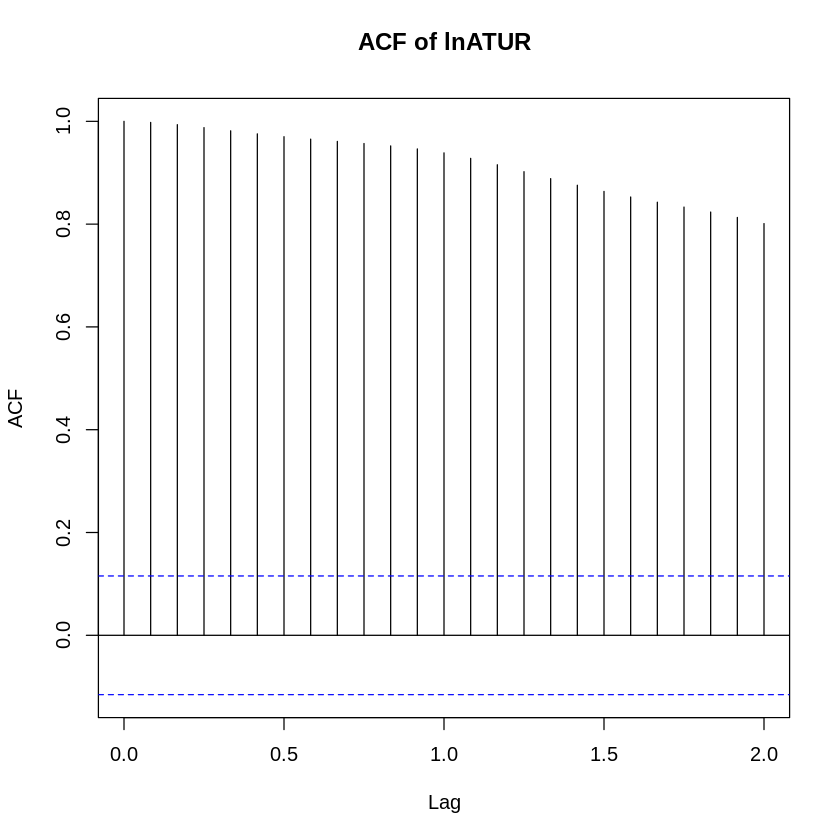

In [ ]:
acf(lnATUR,
    main = "ACF of lnATUR")


ACF: Autocorrelations are high and persistent. Although the plot is dominated by trend, this behavior is consistent with a seasonal series in levels. The dependence structure is compatible with seasonal behavior combined with trend.

**Conclusion:**
The seasonal plot of lnATUR reveals a very strong and systematic monthly seasonal pattern, with unemployment consistently peaking at the beginning of each year and reaching troughs during the summer months. This pattern is highly regular across years, indicating that seasonality is a dominant feature of the series rather than a transitory phenomenon. In parallel, the autocorrelation function of the original ATUR series shows extremely high persistence, with autocorrelations close to one and a very slow decay across lags, which is characteristic of a non-stationary process driven by a strong trend component. The combination of pronounced seasonal fluctuations and high persistence implies that both the mean and variance of ATUR are non-constant in levels. Therefore, the series exhibits clear non-stationarity arising from both deterministic seasonality and stochastic trend, motivating the use of seasonal and first-difference transformations in subsequent analysis.

The dataset exhibits seasonality. Since the data are monthly, the appropriate seasonal period is s = 12. Seasonal differencing is required.

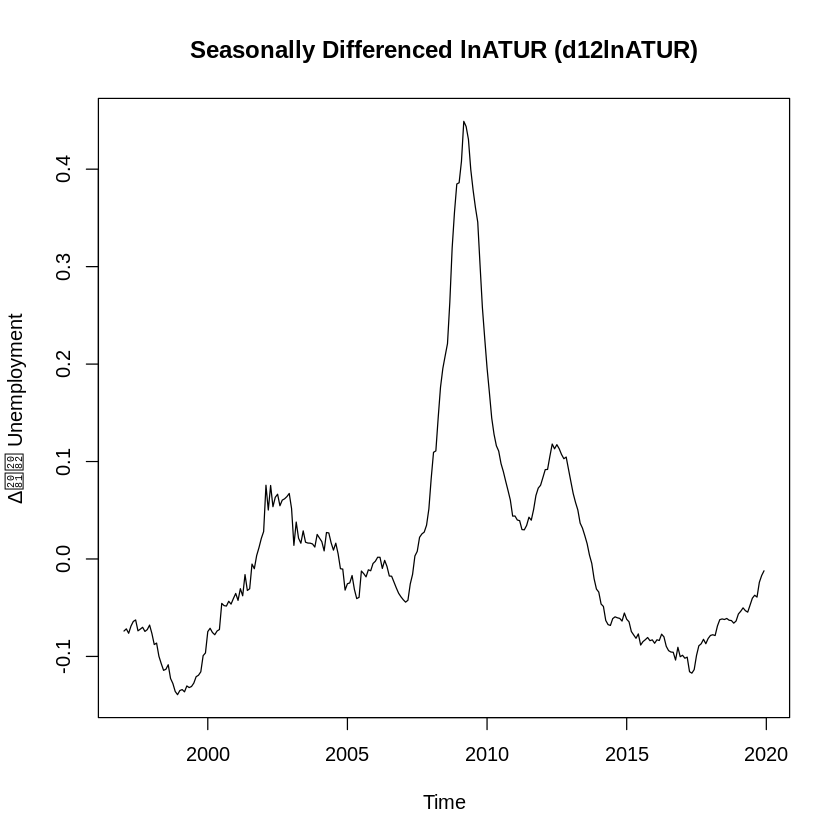

In [ ]:
# Seasonal differencing with period s = 12 (monthly data)
d12ATUR <- diff(lnATUR, lag = 12)

# Plot the seasonally differenced series
plot(d12ATUR,
     main = "Seasonally Differenced lnATUR (d12lnATUR)",
     ylab = "Δ₁₂ Unemployment",
     xlab = "Time")


Seasonal differencing seems to be effective in eliminiating the short term oscillations.

In [ ]:
# Seasonal differencing applied to the log-transformed series
d12lnATUR <- diff(lnATUR, lag = 12)


**Regular Differencing (ATUR)**



The series does not fluctuate around a fixed horizontal level, there are long smooth movements. Large portions of the series stay above or below zero for extended periods. This behavior indicates a time-varying mean, even though seasonality has been removed. Because the mean is still non-constant, we must apply first-order differencing.

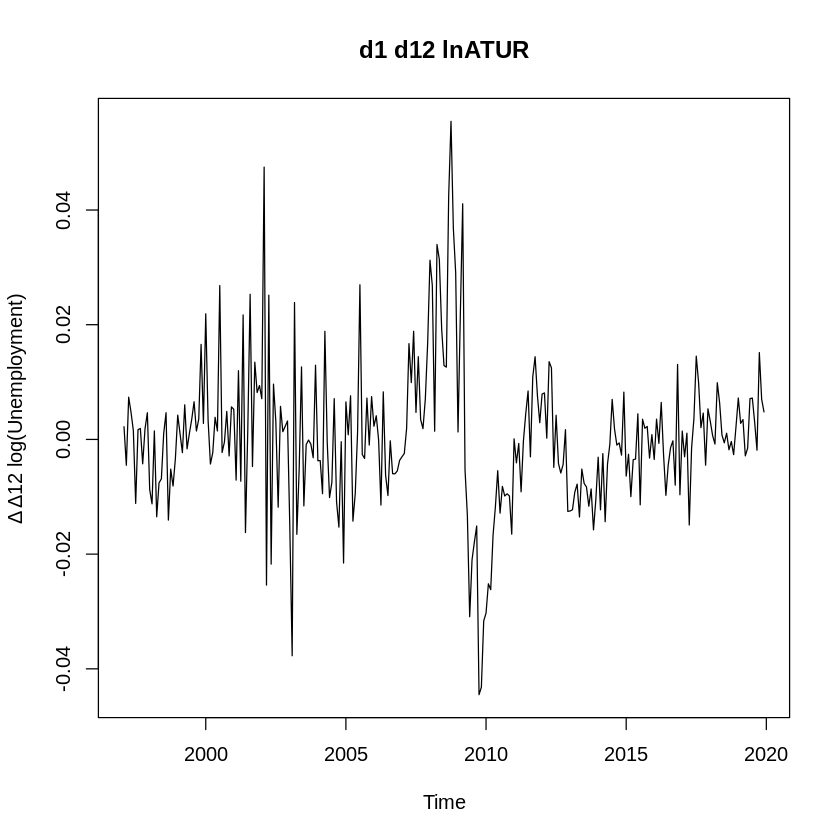

In [ ]:
# First-order differencing of the seasonally differenced log series
d1d12lnATUR <- diff(d12lnATUR)

# Plot
plot(d1d12lnATUR,
     main = "d1 d12 lnATUR",
     ylab = "Δ Δ12 log(Unemployment)",
     xlab = "Time")


Now the series fluctuates around zero for most of the time. Note that there is some non-stationarity around the Spanish financial crisis from 2008-2014, which I would consider as temporal breaks from the stationary structure. Another differencing would not solve that and would risk overdifferencing. There are no persistent upward or downward movements. The mean of d1d12lnATUR can be considered constant.

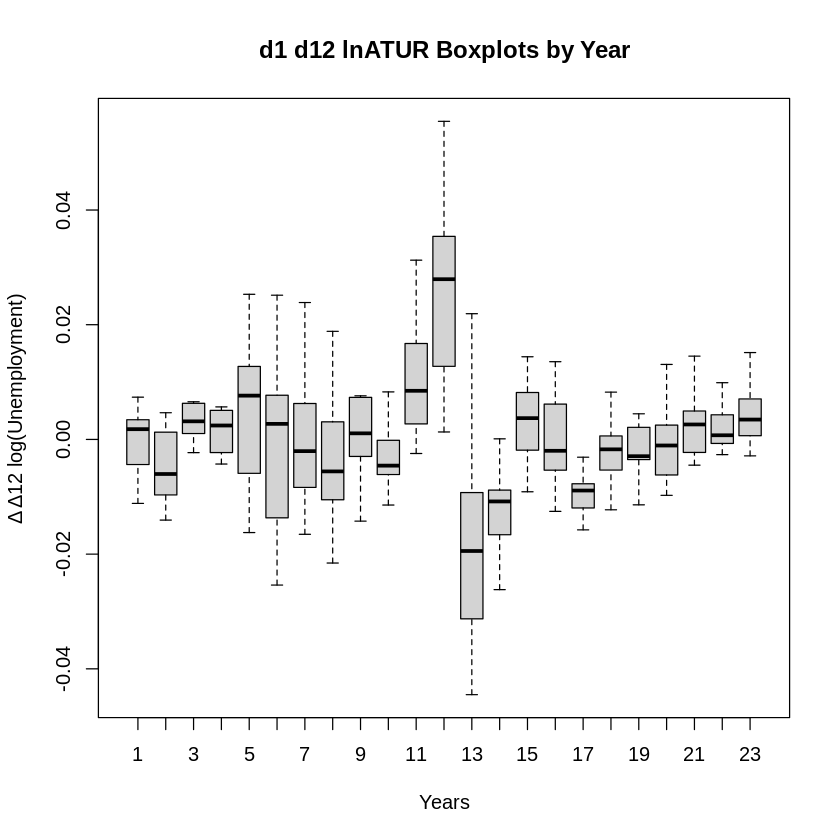

In [ ]:
y <- as.numeric(d1d12lnATUR)
group <- rep(1:ceiling(length(y)/12), each = 12)[1:length(y)]

boxplot(y ~ group,
        xlab = "Years",
        ylab = "Δ Δ12 log(Unemployment)",
        main = "d1 d12 lnATUR Boxplots by Year",
        outline = FALSE)


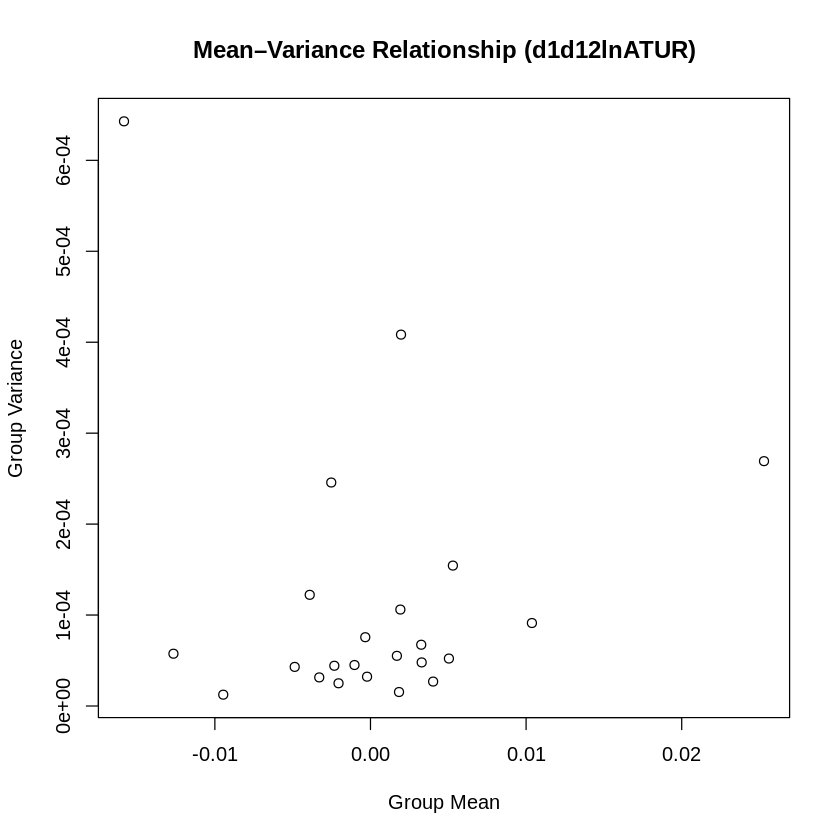

In [ ]:
# Convert to numeric
y <- as.numeric(d1d12lnATUR)

# Yearly groups (12 months)
group <- rep(1:ceiling(length(y)/12), each = 12)[1:length(y)]

# Mean and variance by year
group_mean <- tapply(y, group, mean)
group_var  <- tapply(y, group, var)

# Mean–variance plot
plot(group_mean, group_var,
     xlab = "Group Mean",
     ylab = "Group Variance",
     main = "Mean–Variance Relationship (d1d12lnATUR)")


Check on variance: The spread of the boxes is fairly similar across years (ignoring the crisis). There is no systematic widening or narrowing over time. Also, there is no clear monotonic relationship between group mean and group variance. Variance can be considered constant.

**Final Conclusion:** With a constant mean, constant variance, and removed seasonality, we can treat d1d12lnAtur as approximately weakly stationary.  

# AIRBCN

#### We now continue the analysis for the AirBCN series.

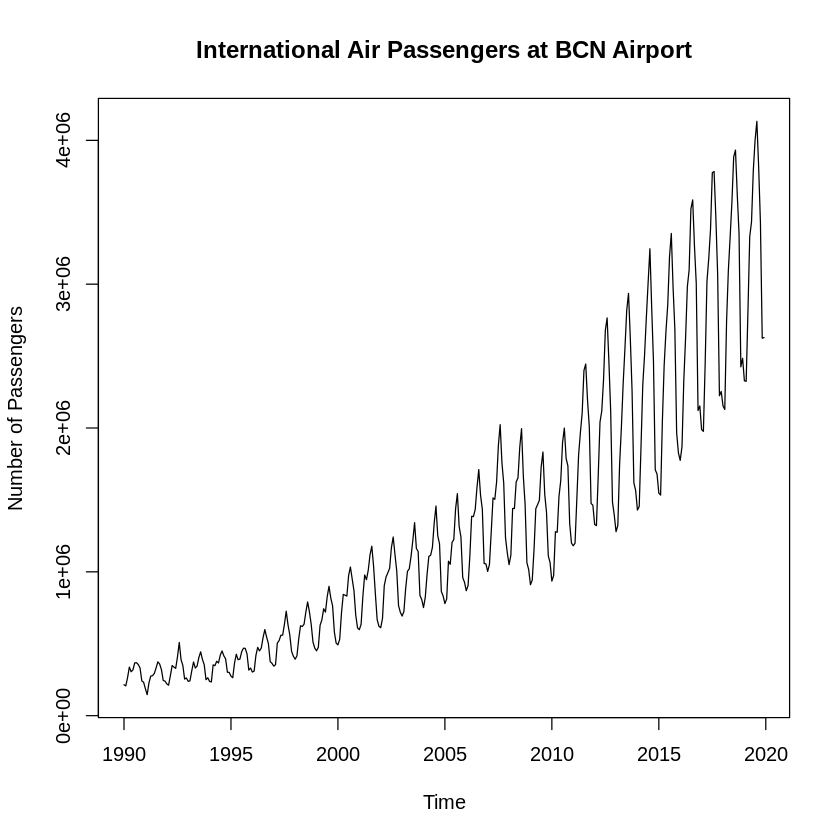

In [ ]:
# Load the data file
airbcn_raw <- scan("/content/sample_data/AirBCN.dat")

# Convert to monthly time series: from Jan 1990 to Dec 2019
AirBCN <- ts(airbcn_raw,
             start = c(1990, 1),
             frequency = 12)

# Plot the AirBCN time series
plot(AirBCN,
     main = "International Air Passengers at BCN Airport",
     ylab = "Number of Passengers",
     xlab = "Time")



The time series of AIRBCN displays a strong upward trend over the entire sample period, reflecting the sustained growth in international air traffic at Barcelona’s airport. Superimposed on this trend is a very pronounced and regular seasonal pattern, with clear peaks and troughs repeating every year, whose amplitude increases over time. This indicates that seasonal fluctuations scale with the level of the series, suggesting the presence of multiplicative seasonality. The variance is clearly non-constant, as fluctuations become progressively larger as the mean increases, pointing to heteroskedasticity in levels. There is no indication of mean reversion in the raw series, and the combination of trend growth, strong seasonality, and increasing variance implies that AIRBCN is highly non-stationary in both mean and variance. These features motivate the use of logarithmic transformation and seasonal differencing in subsequent analysis.

**Is Variance Constant? (AirBCN)**

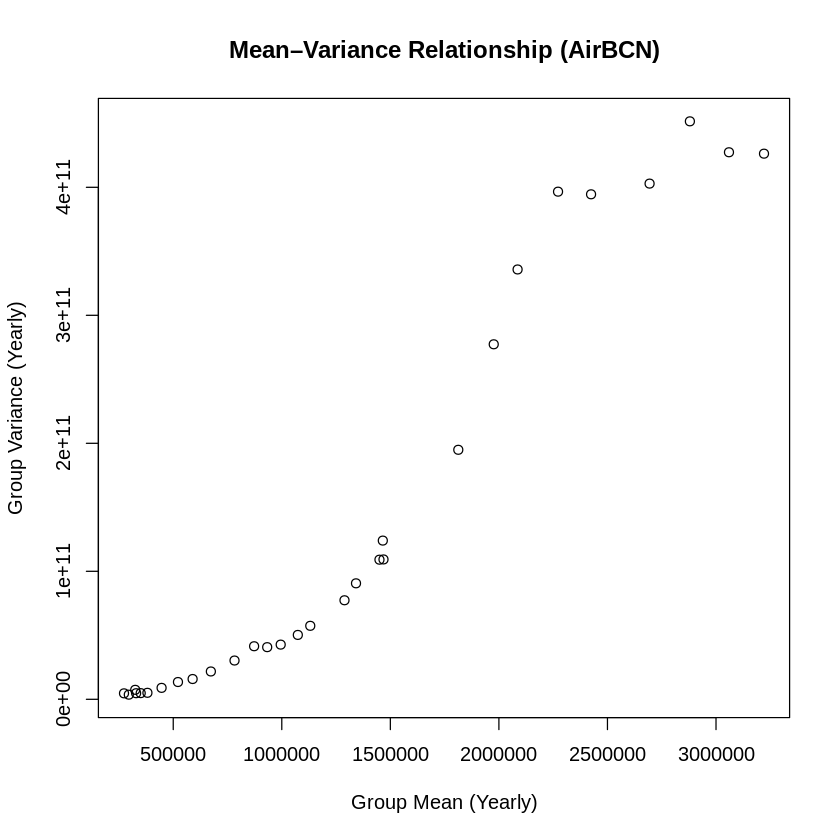

In [ ]:
# Convert to numeric
y <- as.numeric(AirBCN)

# Create yearly groups (12 months)
group <- rep(1:ceiling(length(y)/12), each = 12)[1:length(y)]

# Compute mean and variance by year
group_mean <- tapply(y, group, mean)
group_var  <- tapply(y, group, var)

# Plot mean–variance relationship
plot(group_mean, group_var,
     xlab = "Group Mean (Yearly)",
     ylab = "Group Variance (Yearly)",
     main = "Mean–Variance Relationship (AirBCN)")


Mean-Variance Plot: There is a strong positive relationship between the Group Mean and the Group Variance. Variance is clearly not stable and the time series non stationary.

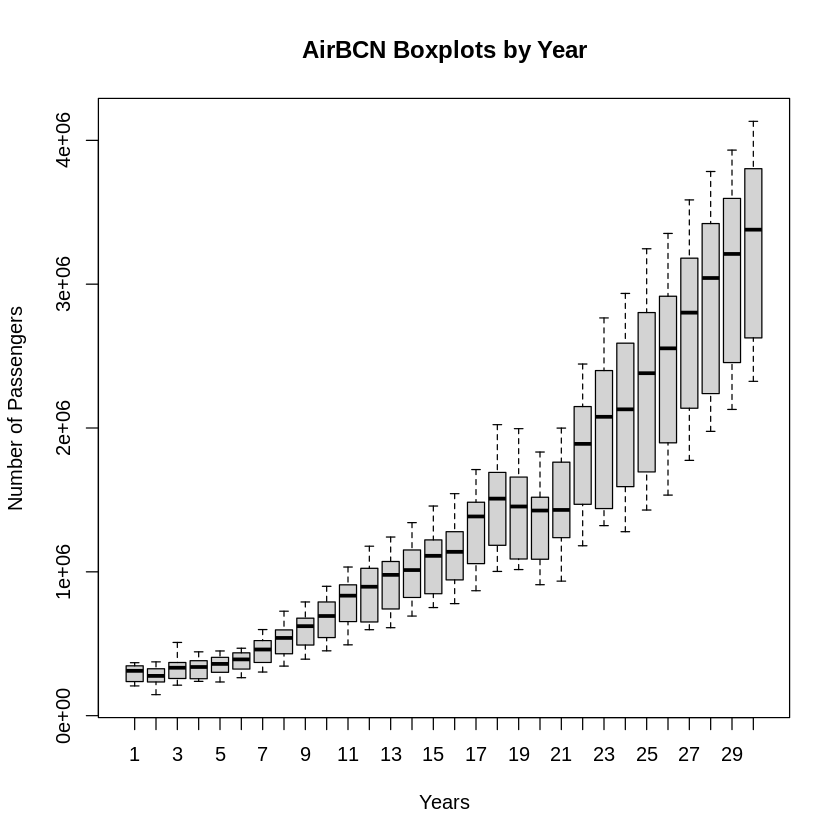

In [ ]:
boxplot(y ~ group,
        xlab = "Years",
        ylab = "Number of Passengers",
        main = "AirBCN Boxplots by Year",
        outline = FALSE)


Boxplot: The spread of the boxplots increasaes steadily over time.

**Conclusion:** AirBCN has non-constant variance. A log transformation is appropriate to stabilise variance.

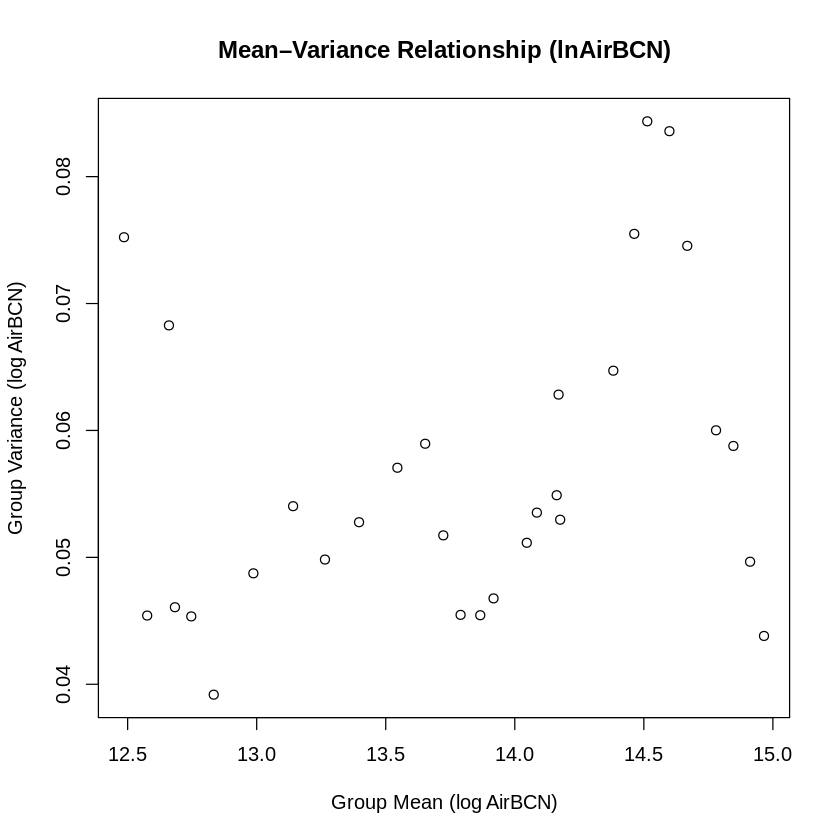

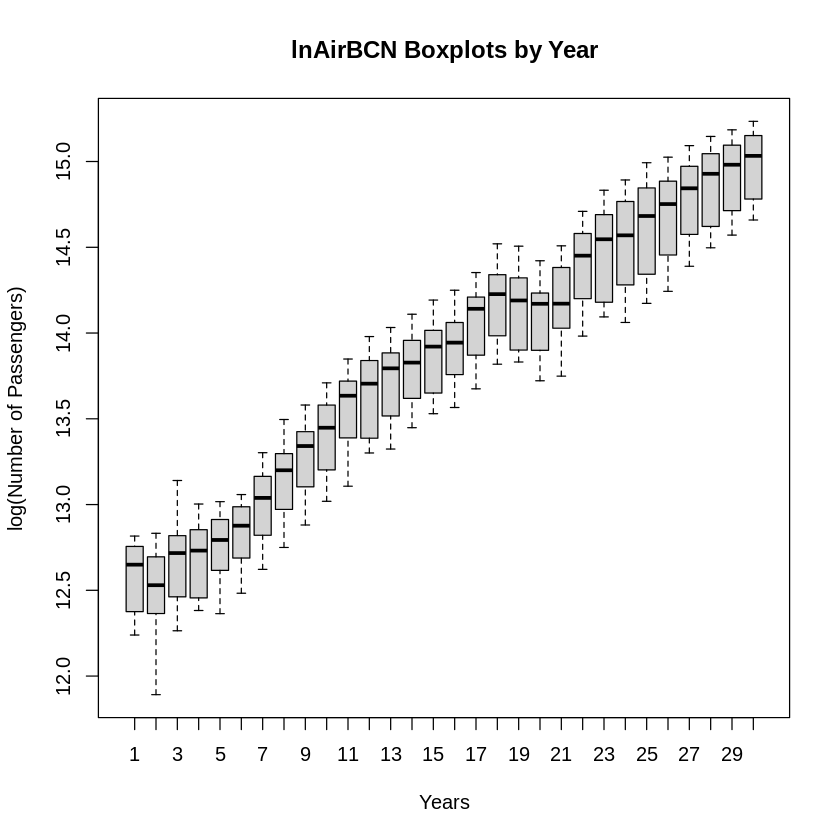

In [ ]:
# Log-transform the AirBCN series
lnAirBCN <- log(AirBCN)

# Convert to numeric
y_ln <- as.numeric(lnAirBCN)

# Yearly groups (12 months)
group <- rep(1:ceiling(length(y_ln)/12), each = 12)[1:length(y_ln)]

# Mean and variance by year
group_mean_ln <- tapply(y_ln, group, mean)
group_var_ln  <- tapply(y_ln, group, var)

# Mean–variance plot (log data)
plot(group_mean_ln, group_var_ln,
     xlab = "Group Mean (log AirBCN)",
     ylab = "Group Variance (log AirBCN)",
     main = "Mean–Variance Relationship (lnAirBCN)")
boxplot(y_ln ~ group,
        xlab = "Years",
        ylab = "log(Number of Passengers)",
        main = "lnAirBCN Boxplots by Year",
        outline = FALSE)


After the log-transformation the variance no longer has an increasing pattern and the box-plots have a fairly constant spread.

The log transform largely stabilizes variability across time (spread is fairly constant), supporting the transformation; however, the level still trends upward in logs, so additional detrending/differencing will be needed for stationarity.

**Seasonality (AirBCN)**

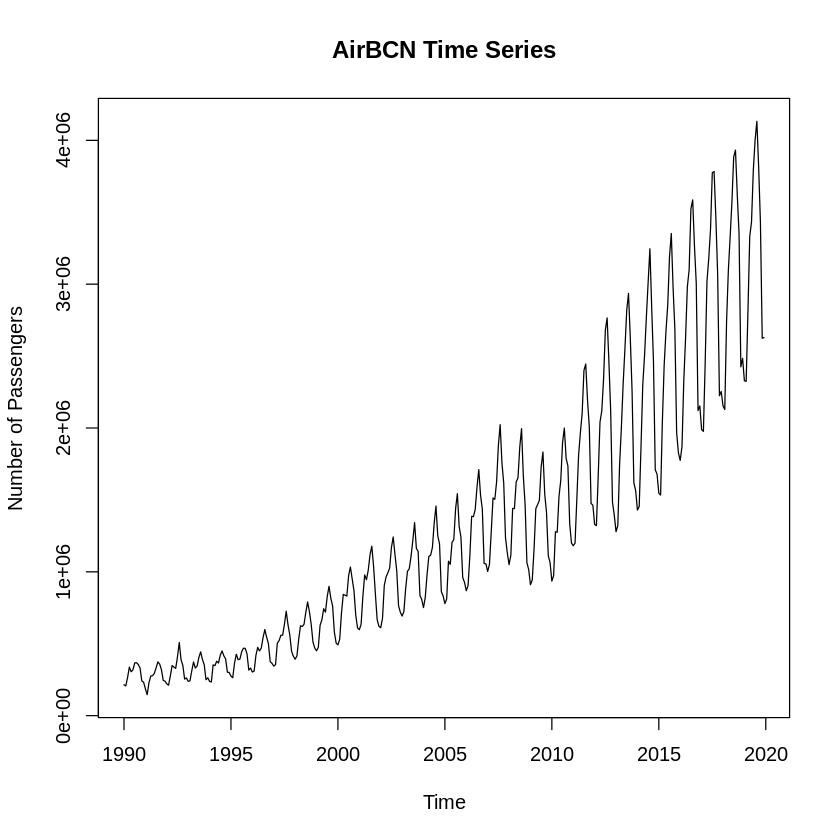

In [ ]:
plot(AirBCN,
     main = "AirBCN Time Series",
     ylab = "Number of Passengers",
     xlab = "Time")


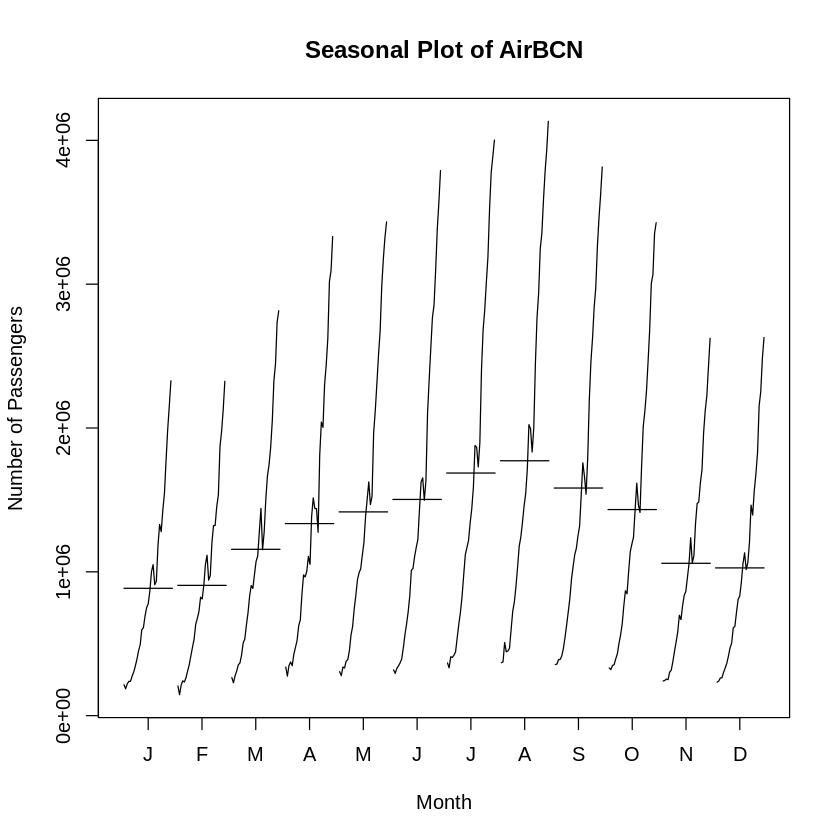

In [ ]:
monthplot(AirBCN,
          main = "Seasonal Plot of AirBCN",
          ylab = "Number of Passengers",
          xlab = "Month")


Monthplot: There is a strong and regular monthly seasonal pattern. Passenger numbers tend to be systemtically low in winter months and higher in summer months.

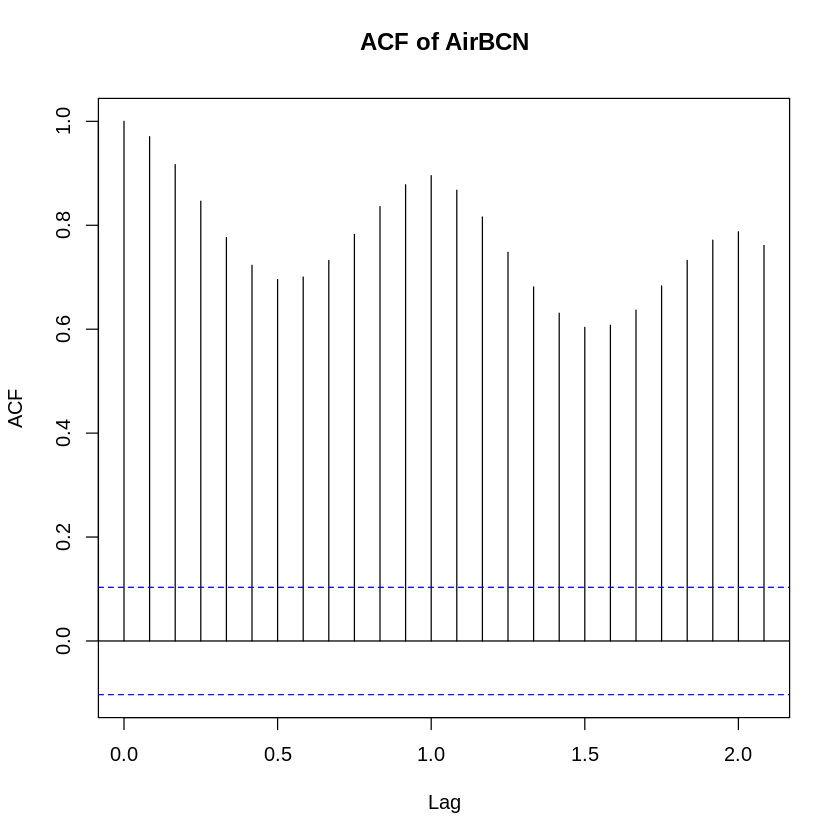

In [ ]:
acf(AirBCN,
    main = "ACF of AirBCN")


The ACF also shows clear cyclical behavior, as the autocorrelations remain high and display a wave-like pattern.

**Conclusion:** There is strong evidence of seasonal dependence at lag 12 and its multiples. Seasonal differencing (s12) is required to remove the seasonal component.

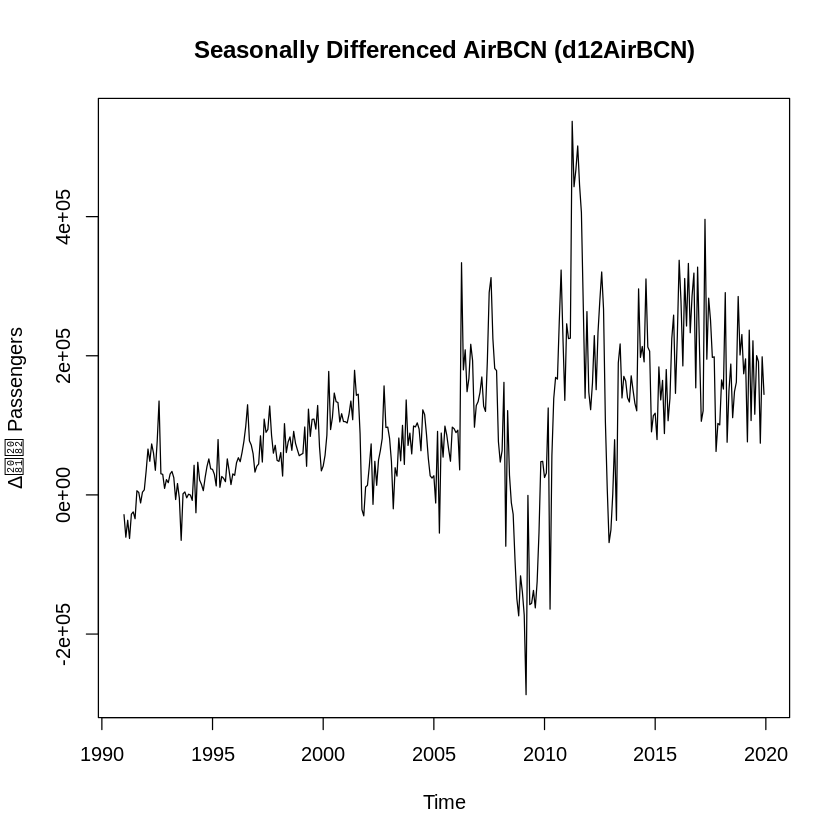

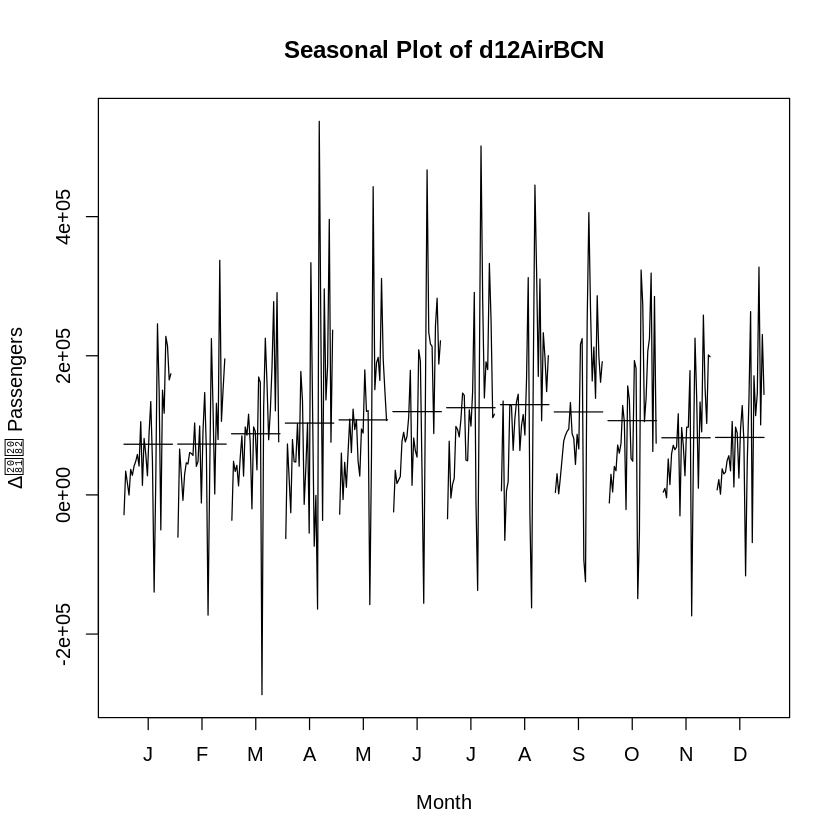

In [ ]:
# Seasonal differencing (monthly, s = 12)
d12AirBCN <- diff(AirBCN, lag = 12)

# Plot the seasonally differenced series
plot(d12AirBCN,
     main = "Seasonally Differenced AirBCN (d12AirBCN)",
     ylab = "Δ₁₂ Passengers",
     xlab = "Time")

monthplot(d12AirBCN,
          main = "Seasonal Plot of d12AirBCN",
          ylab = "Δ₁₂ Passengers",
          xlab = "Month")



The seasonally differenced plot does not have a clearly visible monthly pattern anymore. Also, the seasonal pattern in the monthplot is massively reduced.

**Regular Differencing (AirBCN)**

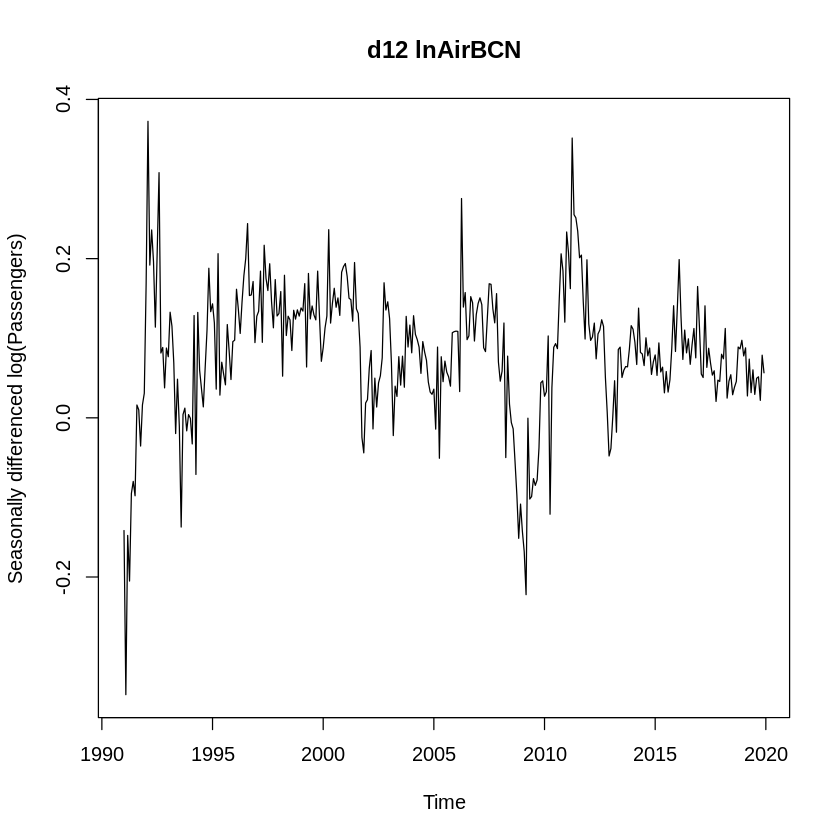

In [ ]:
# Seasonal differencing of the log-transformed series
d12lnAirBCN <- diff(lnAirBCN, lag = 12)

plot(d12lnAirBCN,
     main = "d12 lnAirBCN",
     ylab = "Seasonally differenced log(Passengers)",
     xlab = "Time")


The series does not fluctuate tightly around a fixed level. Large medium-term movements remain after removing seasonality. This indicates a time-varying mean, even though seasonality has been removed and variance has been stabilised using log-transformation. Because the mean is still non-constant, we must apply first-order differencing.

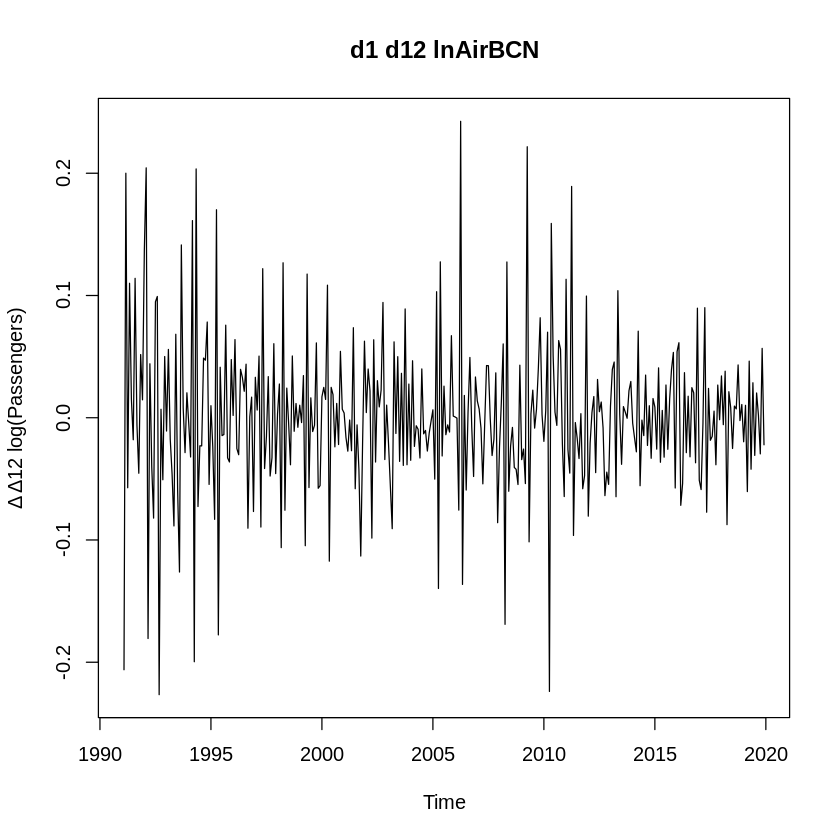

In [ ]:
# First-order differencing of the current series
d1d12lnAirBCN <- diff(d12lnAirBCN)

# Plot to verify
plot(d1d12lnAirBCN,
     main = "d1 d12 lnAirBCN",
     ylab = "Δ Δ12 log(Passengers)",
     xlab = "Time")


The series fluctuates around zero. There is no visible upward or downward drift and positive and negative values alternate frequently. After first-order differencing, the mean can be considered constant and no further differencing seems necessary.

Lets verify the variance:




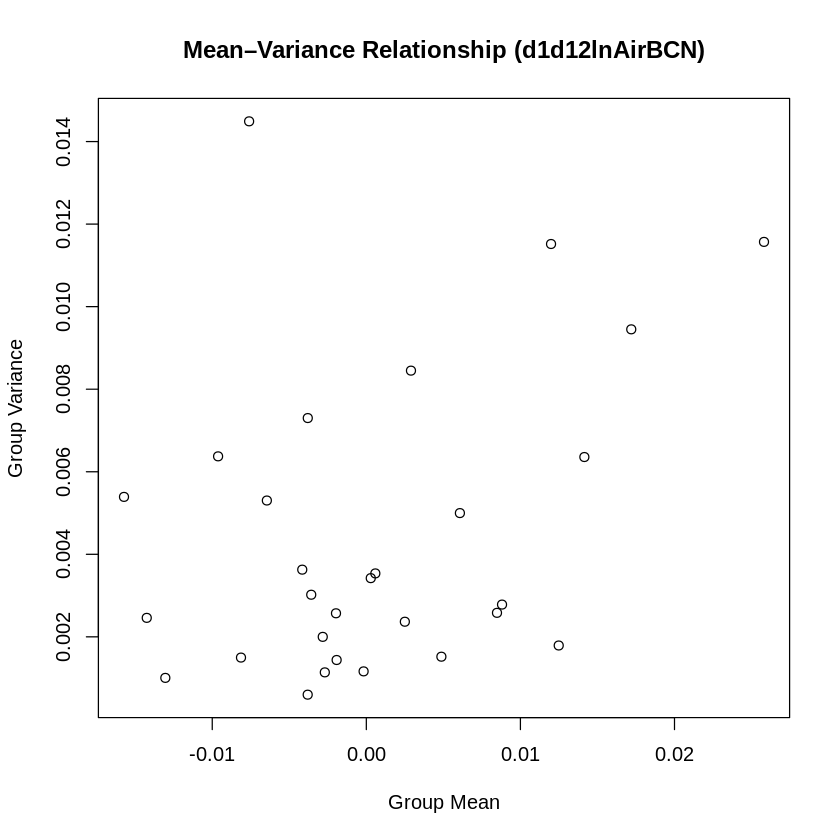

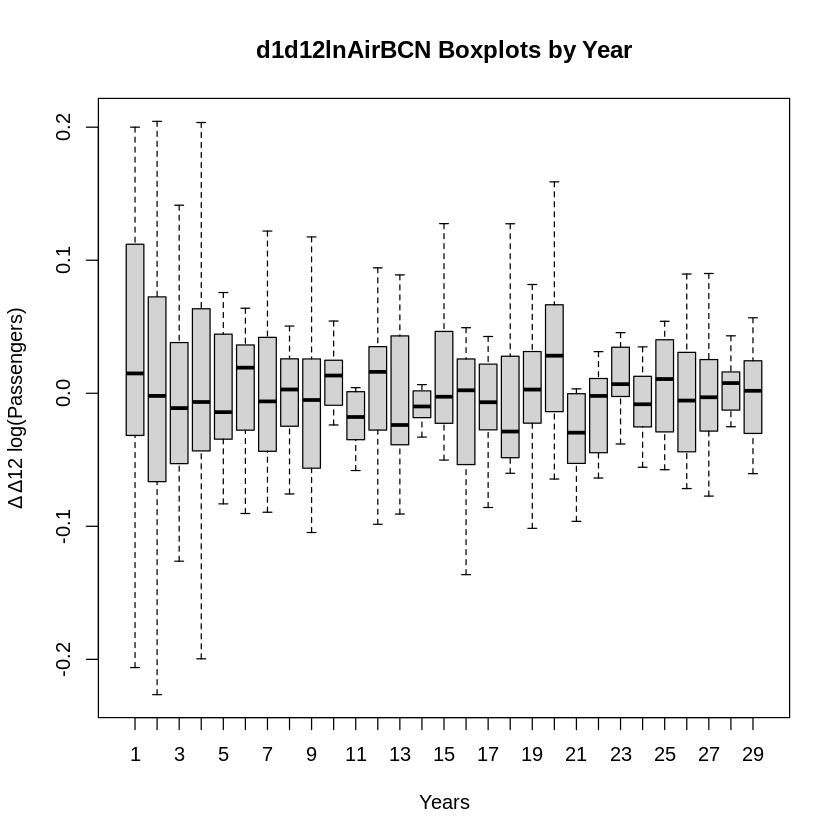

In [ ]:
# Convert to numeric
y <- as.numeric(d1d12lnAirBCN)

# Yearly groups (12 months)
group <- rep(1:ceiling(length(y)/12), each = 12)[1:length(y)]

# Mean and variance by year
group_mean <- tapply(y, group, mean)
group_var  <- tapply(y, group, var)

# Mean–variance plot
plot(group_mean, group_var,
     xlab = "Group Mean",
     ylab = "Group Variance",
     main = "Mean–Variance Relationship (d1d12lnAirBCN)")

# Boxplot

boxplot(y ~ group,
        xlab = "Years",
        ylab = "Δ Δ12 log(Passengers)",
        main = "d1d12lnAirBCN Boxplots by Year",
        outline = FALSE)


The mean-variance plot does not show a relationship between group mean and group variance. This is consistent with constant variance. The interquartile ranges of the boxplots are broadly similar across years and there is no progressive widening or narrowing over time, suggesting variance stability.

**Final Conclusion:** After Log-transformation, Seasonal differencing (s = 12), and First-order differencing the series d1d12lnAirBCN has constant mean and constant variance. It can be treated as weakly stationary.